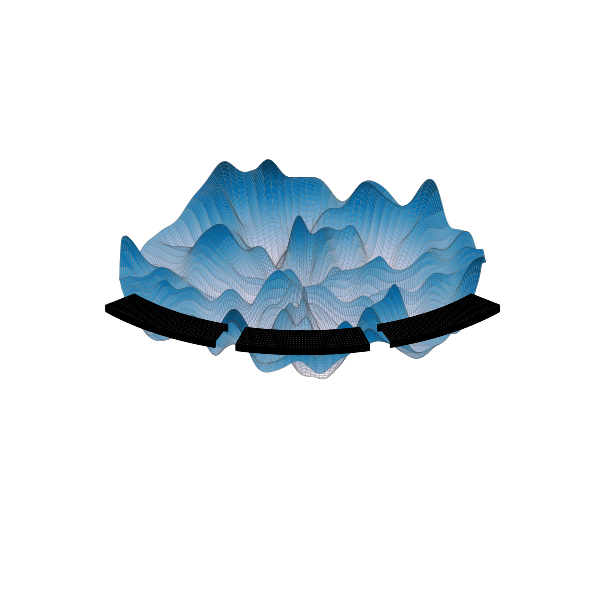

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def set_axes_equal(ax):
    """Equal scale in data units (so spheres look like spheres)."""
    x0, x1 = ax.get_xlim3d()
    y0, y1 = ax.get_ylim3d()
    z0, z1 = ax.get_zlim3d()
    xm, ym, zm = (x0 + x1) / 2, (y0 + y1) / 2, (z0 + z1) / 2
    r = max((x1 - x0), (y1 - y0), (z1 - z0)) / 2
    ax.set_xlim3d(xm - r, xm + r)
    ax.set_ylim3d(ym - r, ym + r)
    ax.set_zlim3d(zm - r, zm + r)

def front_mask(t, azim_deg):
    """Keep only points on the front half relative to the camera azimuth."""
    az = np.deg2rad(azim_deg)
    return np.cos(t - az) > 0.0

# ---------- disc domain ----------
rng = np.random.default_rng(7)
r = np.linspace(0.0, 1.0, 260)
theta = np.linspace(0.0, 2*np.pi, 420)
R, TH = np.meshgrid(r, theta, indexing="xy")

X = R * np.cos(TH)
Y = R * np.sin(TH)

# ---------- MORE WIGGLY irregular PES ----------
# base bowl + more azimuthal/radial harmonics
Z = (
    0.28*R**2
    + 0.09*np.sin(6*TH + 5.0*R)
    + 0.07*np.cos(11*R + 3.0*np.sin(TH))
    + 0.05*np.sin(14*TH + 2.0*R**2)
    + 0.04*np.cos(18*TH - 7.0*R)
    + 0.03*np.sin(24*R + 6.0*np.cos(2*TH))
)

# more, smaller bumps (higher-frequency “wiggles”)
n_bumps = 34
for _ in range(n_bumps):
    rk = np.sqrt(rng.uniform(0, 1))      # uniform in area
    thetak = rng.uniform(0, 2*np.pi)
    xk, yk = rk*np.cos(thetak), rk*np.sin(thetak)
    ak = rng.uniform(-0.22, 0.28)       # smaller but more numerous
    sigma = rng.uniform(0.03, 0.085)    # tighter bumps -> wigglier
    Z += ak * np.exp(-((X-xk)**2 + (Y-yk)**2) / (2*sigma**2))

# add fine “texture” waves across the disk
for w in [2.0, 3.2, 4.6, 6.8]:
    ph1, ph2 = rng.uniform(0, 2*np.pi, size=2)
    Z += 0.02*np.sin(w*(4*X + 3*Y) + ph1) + 0.02*np.cos(w*(3*X - 4*Y) + ph2)

# ---------- plot ----------
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# --- PES: opaque + thicker/wider grid lines ---
ax.plot_surface(
    X, Y, Z,
    rstride=3, cstride=3,            # fewer facets -> grid lines read “wider”
    cmap="PuBu",
    alpha=1.0,                       # NOT transparent
    linewidth=0.1,                   # thicker mesh lines
    edgecolor=(0.25, 0.25, 0.25, 1.0),
    antialiased=True,
    shade=True
)

# view
ax.view_init(elev=28, azim=-55)

# clean look: no axes / grid
ax.grid(False)
ax.set_axis_off()
ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)

# limits then equalize data scaling
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
pad = 0.10 * (Z.max() - Z.min())
ax.set_zlim(Z.min() - pad, Z.max() + pad)
set_axes_equal(ax)

# reduce perspective distortion
ax.set_proj_type("ortho")

# ---------- 3D electrodes: opaque GREY polygons w/ BLACK borders ----------
zrange = (Z.max() - Z.min())

R_inner = 1.2
R_outer = 1.4

rim_max = Z[:, -1].max()
clearance = 0.05 * zrange
z_bot_const = rim_max + clearance
height = 0.06 * zrange
z_top_const = z_bot_const + height

arc_width = np.deg2rad(30)

az0 = ax.azim
centers = np.deg2rad([az0 - 35, az0, az0 + 35])
labels = [r"$E_{1}$", r"$E_{2}$", r"$E_{3}$"]

# electrode styling
face_grey = (0.70, 0.70, 0.70, 1.0)  # solid grey fill
edge_black = (0.0, 0.0, 0.0, 1.0)    # solid black borders

for c, lab in zip(centers, labels):
    t_full = np.linspace(c - arc_width/2, c + arc_width/2, 260)
    t = t_full[front_mask(t_full, az0)]
    if t.size == 0:
        continue

    # top face
    s = np.linspace(0, 1, 10)
    T, S = np.meshgrid(t, s, indexing="xy")
    Rr = R_inner + (R_outer - R_inner) * S

    Xtop = Rr * np.cos(T)
    Ytop = Rr * np.sin(T)
    Ztop = np.full_like(Xtop, z_top_const)

    ax.plot_surface(
        Xtop, Ytop, Ztop,
        color=face_grey,
        alpha=1.0,
        shade=True,
        linewidth=1.0,
        edgecolor=edge_black,
        antialiased=True,
        zsort="max"
    )

    # side walls
    zz = np.linspace(0, 1, 16)
    T2, ZZ = np.meshgrid(t, zz, indexing="xy")
    Zo = z_bot_const + ZZ * height

    # outer wall
    Xo = R_outer * np.cos(T2)
    Yo = R_outer * np.sin(T2)
    ax.plot_surface(
        Xo, Yo, Zo,
        color=face_grey,
        alpha=1.0,
        shade=True,
        linewidth=0.9,
        edgecolor=edge_black,
        antialiased=True,
        zsort="max"
    )

    # inner wall
    Xi = R_inner * np.cos(T2)
    Yi = R_inner * np.sin(T2)
    ax.plot_surface(
        Xi, Yi, Zo,
        color=face_grey,
        alpha=1.0,
        shade=True,
        linewidth=0.9,
        edgecolor=edge_black,
        antialiased=True,
        zsort="max"
    )

    # label
    t_mid = 0.5 * (t[0] + t[-1])
    r_mid = 0.5 * (R_inner + R_outer)
    x_lab = r_mid * np.cos(t_mid)
    y_lab = r_mid * np.sin(t_mid)
    z_lab = z_top_const + 0.02 * zrange
    ax.text(x_lab, y_lab, z_lab, lab, ha="center", va="center", fontsize=12, color="black")

plt.tight_layout()
plt.show()


1
1
3.141592653589793
0.8


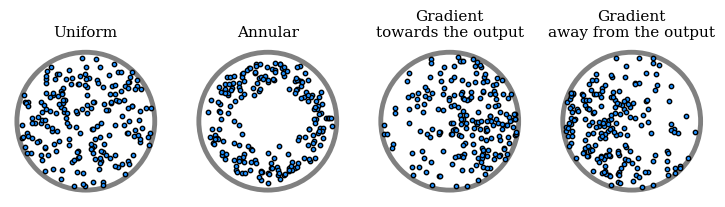

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

fig, axs = plt.subplots(ncols=4, figsize=(9,9))

uni_acc = np.loadtxt('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/uni_1e7/configs/uniform_acceptors_0.txt')
ring_acc = np.loadtxt('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_ring_1e7/configs/vMB_ring.txt')
grad_towards_acc = np.loadtxt('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_towards_1e7/configs/vMB_gradient_towards_output.txt')
grad_away_acc = np.loadtxt('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_away_1e7/configs/vMB_gradient_away_output.txt')

params = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_away_1e7/configs/params.npz')
print(params['a'])
print(params['b'])
print(params['mu'])
print(params['kappa'])

plot_kwargs = {
    's': 10,
    'ec': 'k',
    'fc': 'dodgerblue'
}

pad_radius = 2.5
radius = 150.0

for a in axs:
    a.set_box_aspect(1)
    a.tick_params(left=False, bottom=False, labelbottom=False, labelleft=False)
    a.spines[:].set_visible(False)
    a.add_patch(ps.Circle(xy=(0,0), radius=radius+pad_radius, fill=None, lw=3.5, color='gray'))    

axs[0].scatter(*uni_acc.T, **plot_kwargs)
axs[1].scatter(*ring_acc.T, **plot_kwargs)
axs[2].scatter(*grad_towards_acc.T, **plot_kwargs)
axs[3].scatter(*grad_away_acc.T, **plot_kwargs)

axs[0].set_title(label=r"Uniform")
axs[1].set_title(label=r"Annular")
axs[2].set_title(label=r"Gradient" "\n" "towards the output")
axs[3].set_title(label=r"Gradient" "\n" "away from the output")

plt.savefig('acceptor_distributions_datasets.pdf', bbox_inches='tight')
plt.show()

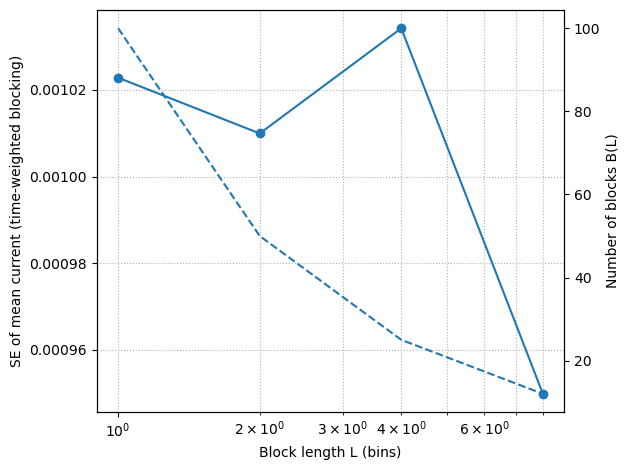

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("/gpfs/bwfor/work/ws/hd_gy283-my_data/burnins_ed=0.1_a=20_steps=10e6/blocking_se_0.txt", skip_header=1)
L  = data[:,0]
B  = data[:,1]
SE = data[:,2]

fig, ax = plt.subplots()
ax.plot(L, SE, marker='o')
ax.set_xscale('log')
ax.set_xlabel("Block length L (bins)")
ax.set_ylabel("SE of mean current (time-weighted blocking)")
ax.grid(True, which="both", linestyle=":")

ax2 = ax.twinx()
ax2.plot(L, B, linestyle="--")
ax2.set_ylabel("Number of blocks B(L)")

plt.tight_layout()
plt.show()

['a', 'b', 'mu', 'kappa']
1
1
3.141592653589793
0.8


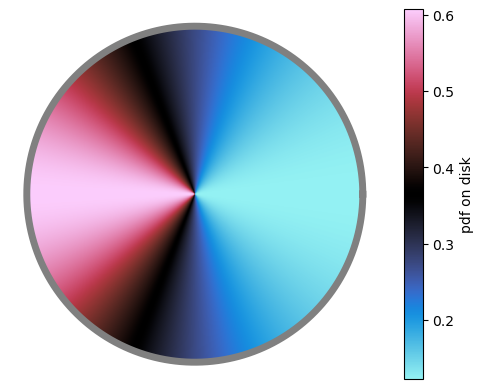

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import cmasher as cmr
from scipy.special import i0  # modified Bessel I0

def vonmises_pdf(theta, kappa, mu=0.0):
    # theta, mu in radians
    return np.exp(kappa*np.cos(theta - mu)) / (2*np.pi*i0(kappa))

dist_params = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_gradient_away_output_1e7/configs/params.npz')
print(dist_params.files)
print(dist_params['a'])
print(dist_params['b'])
print(dist_params['mu'])
print(dist_params['kappa'])

R = 1
mu = dist_params['mu']
kappa = dist_params['kappa']

n = 500
x = np.linspace(-R, R, n)
y = np.linspace(-R, R, n)
X, Y = np.meshgrid(x, y)

r = np.sqrt(X**2 + Y**2)
theta = np.arctan2(Y, X)

# --- 2D pdf on disk: uniform-in-area radial * von Mises angle ---
f_theta = vonmises_pdf(theta, kappa=kappa, mu=mu)
pdf = (2.0 / R**2) * f_theta
pdf[r > R] = np.nan  # mask outside disk

# --- plot ---
fig, ax = plt.subplots()
pad = 0.1
ax.set_xlim(-R - pad, R + pad)
ax.set_ylim(-R - pad, R + pad)

cmap = plt.get_cmap('cmr.redshift')
im = ax.imshow(pdf, extent=[-R, R, -R, R], origin="lower", cmap=cmap)
fig.colorbar(im, ax=ax, label="pdf on disk")

# draw circle boundary
t = np.linspace(0, 2*np.pi, 400)
ax.plot(R*np.cos(t), R*np.sin(t), lw=5, color='gray')

ax.set_box_aspect(1)
ax.spines[:].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

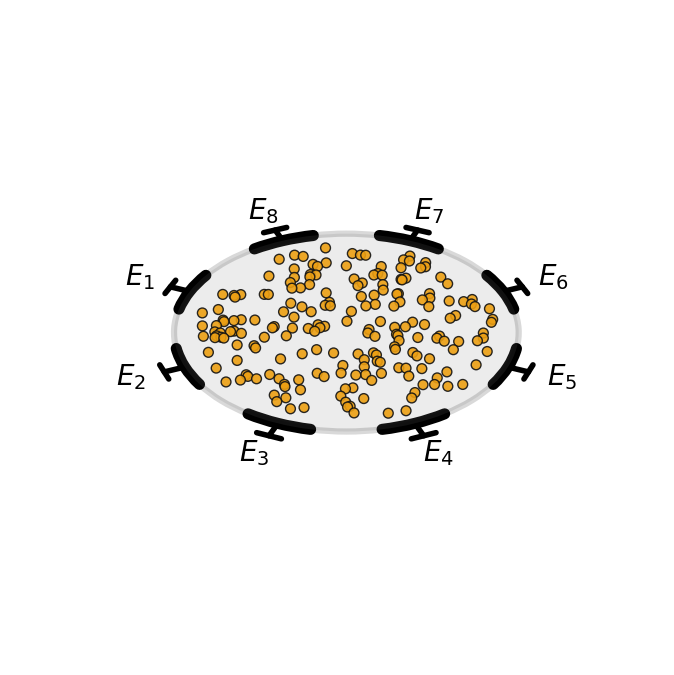

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc
from mpl_toolkits.mplot3d import art3d
import numpy as np
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 15,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 11,    # affects horizontal colorbar ticks
    "ytick.labelsize": 11,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 11,
    "axes.labelsize": 15,
    "legend.fontsize": 11,
})


def scatter_ground_and_layer(
    x1, y1, x2, y2,
    h=0.0,
    c1=None, c2=None,
    s1=50, s2=60,
    show_shadows=False,
    show_ground_plane=False,
    ground_circle_center=(0.5, 0.5),
    ground_circle_radius=0.6,
    ground_circle_color="lightblue",
    ground_circle_alpha=0.15,

    # --- electrodes ---
    add_electrodes=True,
    n_electrodes=8,
    electrode_radius=None,          # if None, uses ground_circle_radius
    electrode_arc_deg=22,           # arc length (degrees) per electrode
    electrode_color="k",
    electrode_lw=8.0,
    electrode_z=0.0,                # tiny lift to avoid z-fighting

    # --- electrode labels ---
    add_electrode_labels=True,
    electrode_label_offset=0.04,    # radial offset outside arc
    electrode_label_fontsize=16,

    # --- handlebars ---
    add_handlebars=True,
    handle_stem_len=0.10,           # radial stem length
    handle_bar_len=0.12,            # tangential bar total length
    handle_lw=4.0,
    handle_color="k",
):
    """
    Plot two scatters in 3D: one on the ground (z=0) and one at height h.
    Adds an optional circle on the ground plane.
    Adds optional electrode arcs + handlebars on the circle boundary.
    Adds optional labels E_i on each electrode arc.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatter(s)
    ax.scatter(x1, y1, z1, c='orange', s=s1, alpha=0.9, edgecolors="k", zorder=5)

    # (If you want the second scatter, uncomment)
    # ax.scatter(x2, y2, z2, c='dodgerblue', s=s2, alpha=0.9, edgecolors="k", zorder=6)

    # ---- ground circle fill ----
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        facecolor='gray',
        edgecolor='k',
        lw=4.5,
        zorder=4,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # ---- electrodes as separated arcs on boundary ----
    if add_electrodes:
        cx, cy = ground_circle_center
        R = ground_circle_radius if electrode_radius is None else electrode_radius

        sector = 360.0 / n_electrodes
        gap = max(0.0, sector - electrode_arc_deg)  # leftover angle becomes gap

        for i in range(n_electrodes):
            # Center of this electrode in degrees
            theta_c = i * sector

            # Arc start/end (leave half the gap on each side)
            theta1 = theta_c + gap / 2.0
            theta2 = theta1 + electrode_arc_deg

            # Arc patch (2D), then lifted into 3D
            arc = Arc(
                (cx, cy),
                width=2 * R,
                height=2 * R,
                angle=0,
                theta1=theta1,
                theta2=theta2,
                color=electrode_color,
                lw=electrode_lw,
                capstyle="round",
                zorder=10
            )
            ax.add_patch(arc)
            art3d.pathpatch_2d_to_3d(arc, z=electrode_z, zdir="z")

            # Midpoint angle (radians) for this electrode (used by labels + handlebars)
            theta_mid = np.deg2rad((theta1 + theta2) / 2.0)

            # ---- handlebar: small radial stem + tangential bar at the end ----
            if add_handlebars:
                # radial stem from R to R + stem
                x0 = cx + R * np.cos(theta_mid)
                y0 = cy + R * np.sin(theta_mid)
                x1h = cx + (R + handle_stem_len) * np.cos(theta_mid)
                y1h = cy + (R + handle_stem_len) * np.sin(theta_mid)

                ax.plot(
                    [x0, x1h], [y0, y1h], [electrode_z, electrode_z],
                    color=handle_color, lw=handle_lw, solid_capstyle="round"
                )

                # tangential bar centered at (x1h, y1h)
                # tangent unit vector = (-sin, cos)
                tx = -np.sin(theta_mid)
                ty =  np.cos(theta_mid)
                half = handle_bar_len / 2.0

                xb0 = x1h - half * tx
                yb0 = y1h - half * ty
                xb1 = x1h + half * tx
                yb1 = y1h + half * ty

                ax.plot(
                    [xb0, xb1], [yb0, yb1], [electrode_z, electrode_z],
                    color=handle_color, lw=handle_lw, solid_capstyle="round"
                )

            # ---- electrode label E_i ----
            if add_electrode_labels:
                label_r = R + (handle_stem_len if add_handlebars else 0.0) + electrode_label_offset
                xl = cx + label_r * np.cos(theta_mid)
                yl = cy + label_r * np.sin(theta_mid)
                zl = electrode_z + 1e-3  # tiny lift to avoid z-fighting

                ax.text(
                    xl, yl, zl,
                    rf"$E_{{{i+1}}}$",   # E_1 .. E_n (change to {i} for 0-indexed)
                    ha="center", va="center",
                    fontsize=electrode_label_fontsize,
                    color=electrode_color
                )

    # Optional: translucent ground plane
    if show_ground_plane:
        xmin, xmax = np.min([np.min(x1), np.min(x2)]), np.max([np.max(x1), np.max(x2)])
        ymin, ymax = np.min([np.min(y1), np.min(y2)]), np.max([np.max(y1), np.max(y2)])
        Xp, Yp = np.meshgrid(np.linspace(xmin, xmax, 2), np.linspace(ymin, ymax, 2))
        Zp = np.zeros_like(Xp)
        ax.plot_surface(Xp, Yp, Zp, alpha=0.08, rstride=1, cstride=1, linewidth=0)

    # Clean up axes
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=35, azim=135)

    plt.tight_layout()
    plt.savefig('dnpu_workflow.pdf', bbox_inches='tight')
    plt.show()


# --- Example usage ---
if __name__ == "__main__":
    rng = np.random.default_rng(42)

    radius = 0.7
    rs = radius * np.sqrt(rng.uniform(0, 1.0, 200))
    thetas = rng.uniform(0, 2*np.pi, 200)

    x1 = rs * np.cos(thetas)
    y1 = rs * np.sin(thetas)

    x2 = rng.uniform(0.2, 0.8, 3)
    y2 = rng.uniform(0.2, 0.8, 3)

    scatter_ground_and_layer(
        x1, y1, x2, y2,
        h=1.5,
        show_ground_plane=False,
        ground_circle_center=(0.0, 0.0),
        ground_circle_radius=radius + 0.1,

        add_electrodes=True,
        n_electrodes=8,
        electrode_arc_deg=22,

        add_electrode_labels=True,
        electrode_label_offset=0.16,
        electrode_label_fontsize=20,

        add_handlebars=True,
        handle_stem_len=0.10,
        handle_bar_len=0.12,
    )


['current', 'currentStd', 'sem', 'control', 'inputIdx', 'outputIdx']


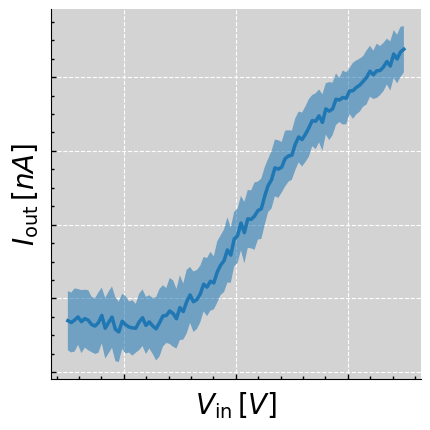

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 16,    # affects horizontal colorbar ticks
    "ytick.labelsize": 2,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 11,
    "axes.labelsize": 20,
    "legend.fontsize": 11,
})

data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/sim_vMB_Silu.npz', allow_pickle=True)
print(data.files)

fig, ax = plt.subplots()
v = np.linspace(-1.5, 1.5, 100)
ax.plot(v, data['current'], lw=2.5, zorder=6)
ax.fill_between(v, data['current'] - 6*data['sem'], data['current'] + 6*data['sem'], alpha=.55, zorder=6)
ax.minorticks_on()
ax.tick_params(direction='in', which='both', width=1.0)
ax.tick_params(labelbottom=False, labelleft=False, direction='in')
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('lightgrey')
ax.grid(True, c='w', ls='dashed', which='major')
ax.set_xlabel(r'$V_{\mathrm{in}} \, [V]$')
ax.set_ylabel(r'$I_{\mathrm{out}} \, [nA]$')
ax.set_box_aspect(1)

plt.savefig('curve_workflow.pdf', bbox_inches='tight')

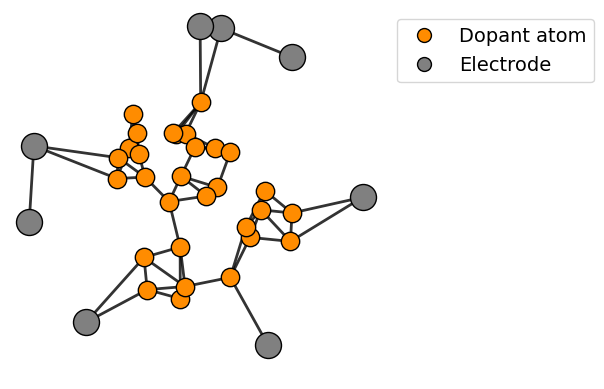

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 20,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 11,    # affects horizontal colorbar ticks
    "ytick.labelsize": 11,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 14,
})

# --- Figure / axes styling ---
fig, ax = plt.subplots()
ax.set_box_aspect(1)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.spines[:].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# --- Generate nodes inside disk + 3 electrode nodes on boundary ---
n = 30
radius = 1.0
np.random.seed(67)

radii = 0.65 * radius * np.sqrt(np.random.uniform(0, 1, size=n))
thetas = 2 * np.pi * np.random.uniform(0, 1, size=n)
x = radii * np.cos(thetas)
y = radii * np.sin(thetas)
ele_color = (0.0, 0.0, 0.0, 0.5)
ele_ang = 2 * np.pi * np.random.uniform(0, 1, size=8)
electrode_nodes = np.array([
    [radius * np.cos(ele_ang[0]), radius * np.sin(ele_ang[0])],
    [radius * np.cos(ele_ang[1]), radius * np.sin(ele_ang[1])],
    [radius * np.cos(ele_ang[2]), radius * np.sin(ele_ang[2])],
    [radius * np.cos(ele_ang[3]), radius * np.sin(ele_ang[3])],
    [radius * np.cos(ele_ang[4]), radius * np.sin(ele_ang[4])],
    [radius * np.cos(ele_ang[5]), radius * np.sin(ele_ang[5])],
    [radius * np.cos(ele_ang[6]), radius * np.sin(ele_ang[6])],
    [radius * np.cos(ele_ang[7]), radius * np.sin(ele_ang[7])]
])

# --- Plot nodes ---
ax.scatter(x, y, s=175, fc="darkorange", ec="k", zorder=3, label='Dopant atom')
ax.scatter(*electrode_nodes.T, s=350, fc='gray', ec="k", zorder=6, label='Electrode')

# --- Build a graph: connect each node to its k nearest neighbors (with optional pruning) ---
points = np.vstack([np.c_[x, y], electrode_nodes])  # include electrodes as nodes too
m = len(points)

k = 3                 # neighbors per node (try 2..5)
max_dist = 0.55       # prune long edges; set None to disable

# pairwise distances (m x m)
diff = points[:, None, :] - points[None, :, :]
D = np.sqrt((diff**2).sum(axis=2))
np.fill_diagonal(D, np.inf)

edges = set()
for i in range(m):
    nn = np.argsort(D[i])[:k]
    for j in nn:
        if (max_dist is None) or (D[i, j] <= max_dist):
            a, b = (i, j) if i < j else (j, i)
            edges.add((a, b))

segments = [(points[i], points[j]) for i, j in edges]
lc = LineCollection(segments, linewidths=2, alpha=0.8, colors="k", zorder=2)
ax.add_collection(lc)

legend_elements = [
    Line2D([0], [0], color='w', markerfacecolor='darkorange', markeredgecolor='k', marker='o', markersize=10, label='Dopant atom'),
    Line2D([0], [0], color='w', markerfacecolor='gray', markeredgecolor='k', marker='o', markersize=10, label='Electrode')
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1.0))
plt.savefig('graph_workflow.pdf', bbox_inches='tight')
plt.show()


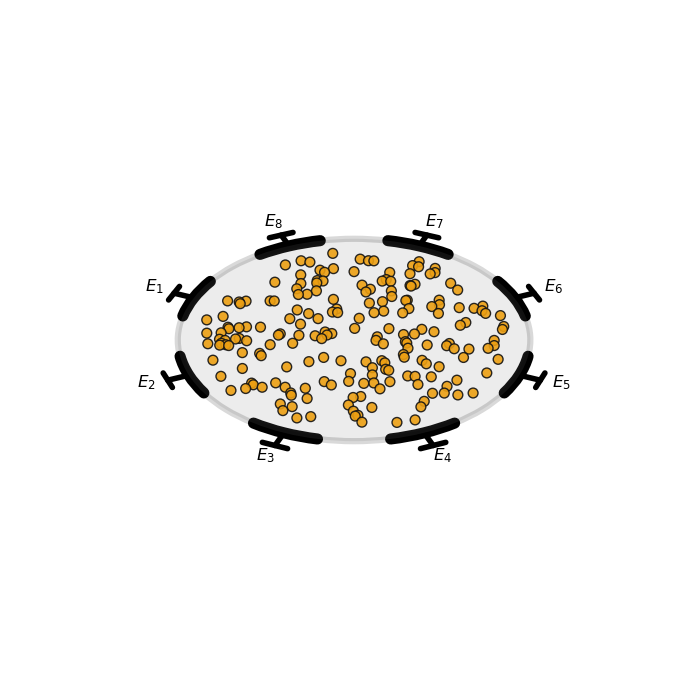

In [115]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc
from mpl_toolkits.mplot3d import art3d
import numpy as np


def scatter_ground_and_layer(
    x1, y1, x2, y2,
    h=0.0,
    c1=None, c2=None,
    s1=50, s2=60,
    show_shadows=False,
    show_ground_plane=False,
    ground_circle_center=(0.5, 0.5),
    ground_circle_radius=0.6,
    ground_circle_color="lightblue",
    ground_circle_alpha=0.15,

    # --- electrodes ---
    add_electrodes=True,
    n_electrodes=8,
    electrode_radius=None,          # if None, uses ground_circle_radius
    electrode_arc_deg=22,           # arc length (degrees) per electrode
    electrode_color="k",
    electrode_lw=8.0,
    electrode_z=0.0,                # tiny lift to avoid z-fighting

    # --- electrode labels ---
    add_electrode_labels=True,
    electrode_label_offset=0.04,    # base radial offset outside arc
    electrode_label_fontsize=12,
    electrode_label_clearance=0.06, # EXTRA clearance beyond handle tip so labels don't touch bars

    # --- handlebars ---
    add_handlebars=True,
    handle_stem_len=0.10,           # radial stem length
    handle_bar_len=0.12,            # tangential bar total length
    handle_lw=4.0,
    handle_color="k",
):
    """
    Plot two scatters in 3D: one on the ground (z=0) and one at height h.
    Adds an optional circle on the ground plane.
    Adds optional electrode arcs + handlebars on the circle boundary.
    Adds optional labels E_i on each electrode arc.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatter(s)
    ax.scatter(x1, y1, z1, c='orange', s=s1, alpha=0.9, edgecolors="k", zorder=5)

    # ---- ground circle fill ----
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        facecolor='gray',
        edgecolor='k',
        lw=4.5,
        zorder=4,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # ---- electrodes as separated arcs on boundary ----
    if add_electrodes:
        cx, cy = ground_circle_center
        R = ground_circle_radius if electrode_radius is None else electrode_radius

        sector = 360.0 / n_electrodes
        gap = max(0.0, sector - electrode_arc_deg)  # leftover angle becomes gap

        for i in range(n_electrodes):
            theta_c = i * sector
            theta1 = theta_c + gap / 2.0
            theta2 = theta1 + electrode_arc_deg

            arc = Arc(
                (cx, cy),
                width=2 * R,
                height=2 * R,
                angle=0,
                theta1=theta1,
                theta2=theta2,
                color=electrode_color,
                lw=electrode_lw,
                capstyle="round",
                zorder=10
            )
            ax.add_patch(arc)
            art3d.pathpatch_2d_to_3d(arc, z=electrode_z, zdir="z")

            theta_mid = np.deg2rad((theta1 + theta2) / 2.0)

            # ---- handlebars ----
            if add_handlebars:
                x0 = cx + R * np.cos(theta_mid)
                y0 = cy + R * np.sin(theta_mid)
                x1h = cx + (R + handle_stem_len) * np.cos(theta_mid)
                y1h = cy + (R + handle_stem_len) * np.sin(theta_mid)

                ax.plot(
                    [x0, x1h], [y0, y1h], [electrode_z, electrode_z],
                    color=handle_color, lw=handle_lw, solid_capstyle="round"
                )

                tx = -np.sin(theta_mid)
                ty =  np.cos(theta_mid)
                half = handle_bar_len / 2.0

                xb0 = x1h - half * tx
                yb0 = y1h - half * ty
                xb1 = x1h + half * tx
                yb1 = y1h + half * ty

                ax.plot(
                    [xb0, xb1], [yb0, yb1], [electrode_z, electrode_z],
                    color=handle_color, lw=handle_lw, solid_capstyle="round"
                )

            # ---- electrode label E_i (pushed further out than the handle tip) ----
            if add_electrode_labels:
                # handle tip radius is R + handle_stem_len (if handlebars are on)
                handle_tip_r = R + (handle_stem_len if add_handlebars else 0.0)

                # ensure label is beyond the handle tip by at least electrode_label_clearance
                label_r = max(
                    R + electrode_label_offset,
                    handle_tip_r + electrode_label_clearance
                )

                xl = cx + label_r * np.cos(theta_mid)
                yl = cy + label_r * np.sin(theta_mid)
                zl = electrode_z + 1e-3

                ax.text(
                    xl, yl, zl,
                    rf"$E_{{{i+1}}}$",
                    ha="center", va="center",
                    fontsize=electrode_label_fontsize,
                    color=electrode_color
                )

    # Optional: translucent ground plane
    if show_ground_plane:
        xmin, xmax = np.min([np.min(x1), np.min(x2)]), np.max([np.max(x1), np.max(x2)])
        ymin, ymax = np.min([np.min(y1), np.min(y2)]), np.max([np.max(y1), np.max(y2)])
        Xp, Yp = np.meshgrid(np.linspace(xmin, xmax, 2), np.linspace(ymin, ymax, 2))
        Zp = np.zeros_like(Xp)
        ax.plot_surface(Xp, Yp, Zp, alpha=0.08, rstride=1, cstride=1, linewidth=0)

    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=35, azim=135)

    plt.tight_layout()
    plt.savefig('dnpu_workflow.pdf', bbox_inches='tight')
    plt.show()


rng = np.random.default_rng(42)

radius = 0.7
rs = radius * np.sqrt(rng.uniform(0, 1.0, 200))
thetas = rng.uniform(0, 2*np.pi, 200)

x1 = rs * np.cos(thetas)
y1 = rs * np.sin(thetas)

x2 = rng.uniform(0.2, 0.8, 3)
y2 = rng.uniform(0.2, 0.8, 3)

scatter_ground_and_layer(
    x1, y1, x2, y2,
    h=1.5,
    show_ground_plane=False,
    ground_circle_center=(0.0, 0.0),
    ground_circle_radius=radius + 0.1,

    add_electrodes=True,
    n_electrodes=8,
    electrode_arc_deg=22,

    add_electrode_labels=True,
    electrode_label_offset=0.05,
    electrode_label_fontsize=12,
    electrode_label_clearance=0.10,  # increase if you want even more space

    add_handlebars=True,
    handle_stem_len=0.10,
    handle_bar_len=0.12,
)


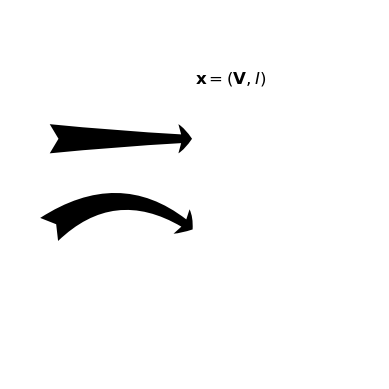

In [64]:
import matplotlib.pyplot as plt
import matplotlib.patches as ps

fig, ax = plt.subplots()

style = "fancy,tail_width=1.5,head_width=1.5,head_length=.7"
kw = dict(arrowstyle=style, facecolor="k", edgecolor="k", linewidth=0, mutation_scale=14)

fancy_arrow = ps.FancyArrowPatch(
    (0.1, 0.4), (0.5, 0.4),
    connectionstyle="arc3,rad=-.4",
    **kw, zorder=6
)

style_2 = "fancy,tail_width=1.5,head_width=1.5,head_length=.7"
kw_2 = dict(arrowstyle=style, facecolor="k", edgecolor="k", linewidth=0, mutation_scale=14)

fancy_arrow_2 = ps.FancyArrowPatch(
    (0.1, 0.65), (0.5, 0.65),
    connectionstyle="arc3,rad=0",
    **kw, zorder=6
)
ax.add_patch(fancy_arrow_2)

ax.add_patch(fancy_arrow)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)
ax.set_aspect("equal", adjustable="box")

ax.text(
    x=0.5, y=0.8,
    s=r'$\mathbf{x} = (\mathbf{V}, I)$',
    fontsize=12)

plt.savefig("fancy_arrow.pdf", bbox_inches='tight')
plt.show()


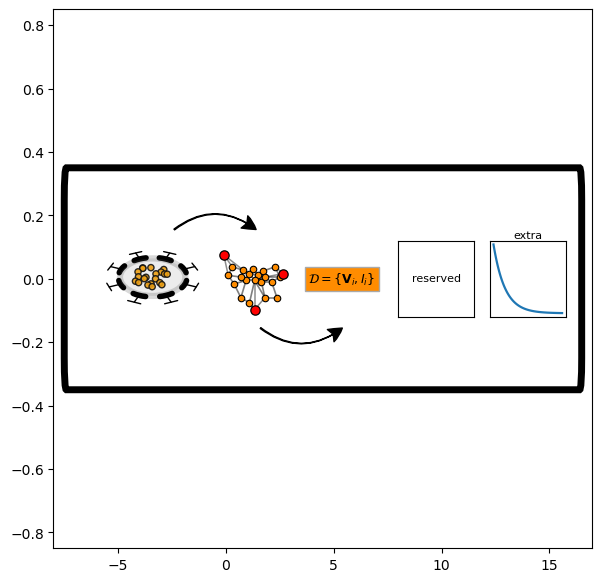

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as ps
from matplotlib.patches import Circle, Arc
from mpl_toolkits.mplot3d import art3d
import numpy as np


def scatter_ground_and_layer(
    ax,                      # <-- pass in an existing 3D axes
    x1, y1, x2, y2,
    h=0.0,
    s1=20, s2=30,
    ground_circle_center=(0.0, 0.0),
    ground_circle_radius=0.8,
    ground_circle_alpha=0.15,

    add_electrodes=True,
    n_electrodes=8,
    electrode_radius=None,
    electrode_arc_deg=22,
    electrode_color="k",
    electrode_lw=4.0,
    electrode_z=0.0,

    add_handlebars=True,
    handle_stem_len=0.10,
    handle_bar_len=0.12,
    handle_lw=1.0,
    handle_color="k",
):
    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatter(s)
    ax.scatter(x1, y1, z1, c='orange', s=s1, alpha=0.9, edgecolors="k", zorder=5)
    # ax.scatter(x2, y2, z2, c='crimson', s=s2, alpha=0.9, edgecolors="k", zorder=6)

    # Ground circle fill
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        facecolor='gray',
        edgecolor='k',
        lw=4.5,
        zorder=4,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # Electrodes as arcs
    if add_electrodes:
        cx, cy = ground_circle_center
        R = ground_circle_radius if electrode_radius is None else electrode_radius
        sector = 360.0 / n_electrodes
        gap = max(0.0, sector - electrode_arc_deg)

        for i in range(n_electrodes):
            theta_c = i * sector
            theta1 = theta_c + gap / 2.0
            theta2 = theta1 + electrode_arc_deg

            arc = Arc(
                (cx, cy),
                width=2.1 * R,
                height=2.1 * R,
                angle=0,
                theta1=theta1,
                theta2=theta2,
                color=electrode_color,
                lw=electrode_lw,
                capstyle="round",
                zorder=10
            )
            ax.add_patch(arc)
            art3d.pathpatch_2d_to_3d(arc, z=electrode_z, zdir="z")

            if add_handlebars:
                theta_mid = np.deg2rad((theta1 + theta2) / 2.0)

                # radial stem
                x0 = cx + R * np.cos(theta_mid)
                y0 = cy + R * np.sin(theta_mid)
                x1h = cx + (R + handle_stem_len) * np.cos(theta_mid)
                y1h = cy + (R + handle_stem_len) * np.sin(theta_mid)

                ax.plot([x0, x1h], [y0, y1h], [electrode_z, electrode_z],
                        color=handle_color, lw=handle_lw, solid_capstyle="round")

                # tangential bar
                tx, ty = -np.sin(theta_mid), np.cos(theta_mid)
                half = handle_bar_len / 2.0
                xb0, yb0 = x1h - half * tx, y1h - half * ty
                xb1, yb1 = x1h + half * tx, y1h + half * ty

                ax.plot([xb0, xb1], [yb0, yb1], [electrode_z, electrode_z],
                        color=handle_color, lw=handle_lw, solid_capstyle="round")

    # Clean 3D axes look
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=35, azim=135)

    return ax


# -------------------------
# Main figure + rectangle
# -------------------------
fig, ax = plt.subplots(figsize=(7, 7))

rect_width = 15
rect_height = 0.7
pad = 0.5

# Make the rectangle wider to the RIGHT to fit one more inset
extra_right = 9.0
rect_left  = -0.5 * rect_width
rect_width_wide = rect_width + extra_right
rect_right = rect_left + rect_width_wide

ax.set_box_aspect(1)
ax.set_xlim(rect_left - pad, rect_right + pad)
ax.set_ylim(-0.5*rect_height - pad, 0.5*rect_height + pad)

rect_box = ps.FancyBboxPatch(
    xy=(rect_left, -0.5*rect_height),
    width=rect_width_wide,
    height=rect_height,
    boxstyle='round,pad=0.0,rounding_size=0.1',
    linewidth=5.0,
    fill=None, zorder=10
)
ax.add_patch(rect_box)

# -----------------------------------------
# Insets laid out left -> right (NOW 5 slots)
# Smaller widths + bigger gaps => more separation
# -----------------------------------------
y0, h0 = 0.35, 0.30
slots = [
    [0.03, y0, 0.3, h0],  # slot 1 (3D)
    [0.30, y0, 0.14, h0],  # slot 2 (graph)
    [0.47, y0, 0.14, h0],  # slot 3 (dataset text)
    [0.64, y0, 0.14, h0],  # slot 4 (placeholder)
    [0.81, y0, 0.14, h0],  # slot 5 (NEW inset on the far right)
]

# --- slot 1: 3D inset ---
ax_3d = ax.inset_axes(slots[0], projection="3d", transform=ax.transAxes)

# --- slot 2: graph inset ---
ax_graph = ax.inset_axes(slots[1], transform=ax.transAxes)
ax_graph.set_xticks([])
ax_graph.set_yticks([])
ax_graph.set_xlim(-1., 1.)
ax_graph.set_ylim(-1., 1.)
ax_graph.set_box_aspect(1)

# --- slot 3: dataset-text inset ---
ax_extra1 = ax.inset_axes(slots[2], transform=ax.transAxes)
ax_extra1.set_box_aspect(1)
ax_extra1.set_xticks([]); ax_extra1.set_yticks([])
ax_extra1.set_xlim(0, 1); ax_extra1.set_ylim(0, 1)
ax_extra1.text(
    x=0.02, y=0.50,
    s=r'$\mathcal{D} = \{ \mathbf{V}_i, I_i \}$',
    fontsize=9,
    va="center",
    bbox=dict(boxstyle="square", ec="darkgray", fc="darkorange"),
)
# hide spines for this "label card"
for sp in ax_extra1.spines.values():
    sp.set_visible(False)

# --- slot 4: placeholder inset ---
ax_extra2 = ax.inset_axes(slots[3], transform=ax.transAxes)
ax_extra2.set_box_aspect(1)
ax_extra2.set_xticks([]); ax_extra2.set_yticks([])
ax_extra2.set_xlim(0, 1); ax_extra2.set_ylim(0, 1)
ax_extra2.text(0.5, 0.5, "reserved", ha="center", va="center", fontsize=8)
ax_extra2.set_frame_on(True)

# --- slot 5: NEW extra inset on the far right ---
ax_extra3 = ax.inset_axes(slots[4], transform=ax.transAxes)
ax_extra3.set_box_aspect(1)

# Example content for the new inset (replace with whatever you want)
t = np.linspace(0, 1, 120)
ax_extra3.plot(t, np.exp(-6*t), lw=1.6)
ax_extra3.set_title("extra", fontsize=8, pad=2)
ax_extra3.set_xticks([]); ax_extra3.set_yticks([])
ax_extra3.set_frame_on(True)


# -------------------------
# Graph content (unchanged)
# -------------------------
graph_node_coords = np.array(
    [
        # core-ish cluster
        [ 0.15,  0.10],  # 0
        [-0.10,  0.15],  # 1
        [ 0.05, -0.05],  # 2
        [ 0.25, -0.10],  # 3
        [-0.20, -0.05],  # 4
        [ 0.00,  0.28],  # 5
        [ 0.28,  0.22],  # 6
        [-0.28,  0.25],  # 7
        [-0.35,  0.05],  # 8
        [ 0.35,  0.05],  # 9

        # left side / upper left
        [-0.60,  0.35],  # 10
        [-0.72,  0.10],  # 11
        [-0.55, -0.15],  # 12

        # bottom / lower left
        [-0.35, -0.55],  # 13
        [-0.10, -0.70],  # 14

        # right / upper right
        [ 0.65,  0.35],  # 15
        [ 0.78,  0.05],  # 16
        [ 0.55, -0.10],  # 17

        # bottom / lower right
        [ 0.35, -0.55],  # 18
        [ 0.70, -0.55],  # 19
    ]
)

ax_graph.scatter(
    *graph_node_coords.T,
    s=22,
    fc="darkorange",
    ec="k",
    lw=0.8,
    zorder=3
)
ax_graph.spines[:].set_visible(False)
ax_graph.set_xlim(-1.1, 1.1)
ax_graph.set_ylim(-1.1, 1.1)

edges = [
    # core mesh
    (0, 1), (0, 2), (0, 3), (1, 2), (1, 4), (2, 4), (3, 2),
    (5, 0), (5, 1), (6, 0), (6, 3), (7, 1), (7, 8), (8, 4),
    (9, 3), (9, 6), (9, 17),

    # left side connections
    (10, 7), (10, 11), (11, 8), (11, 12), (12, 4), (12, 13),

    # bottom connections
    (13, 14), (14, 2), (13, 4),

    # right side connections
    (15, 6), (15, 16), (16, 9), (16, 17), (17, 3),

    # lower right connections
    (18, 3), (18, 2), (18, 19), (19, 17),
]

for i, j in edges:
    xi, yi = graph_node_coords[i]
    xj, yj = graph_node_coords[j]
    ax_graph.plot([xi, xj], [yi, yj], color="k", lw=1.2, alpha=0.5, zorder=2)

red_pts = np.array([
    [-0.85,  0.70],  # upper-left outskirts
    [ 0.88,  0.15],  # right outskirts
    [ 0.05, -0.90],  # bottom outskirts
])
ax_graph.scatter(*red_pts.T, s=45, c="red", edgecolors="k", linewidths=0.9, zorder=4)

red_to_orange = [
    (0, [10, 7, 11]),
    (1, [16, 15, 9]),
    (2, [14, 18, 2]),
]

for r_idx, orange_list in red_to_orange:
    xr, yr = red_pts[r_idx]
    for o_idx in orange_list:
        xo, yo = graph_node_coords[o_idx]
        ax_graph.plot([xr, xo], [yr, yo], color="k", lw=1.1, alpha=0.45, zorder=1)


# -------------------------
# 3D content (unchanged)
# -------------------------
rng = np.random.default_rng(42)
radius = 0.7
rs = radius * np.sqrt(rng.uniform(0, 1.0, 20))
thetas = rng.uniform(0, 2*np.pi, 20)
x1 = rs * np.cos(thetas)
y1 = rs * np.sin(thetas)
x2 = rng.uniform(-0.2, 0.2, 3)
y2 = rng.uniform(-0.2, 0.2, 3)

scatter_ground_and_layer(
    ax_3d,
    x1, y1, x2, y2,
    h=1.5,
    ground_circle_center=(0.0, 0.0),
    ground_circle_radius=radius + 0.5,
    add_electrodes=True,
    n_electrodes=8,
    electrode_arc_deg=22,
    handle_stem_len=.5,
    handle_bar_len=.5,
)

# -------------------------
# Arrows + text (unchanged)
# -------------------------
style = "fancy, tail_width=0.7, head_width=10, head_length=10"
kw = dict(arrowstyle=style, color="k")

mid = 0.5 * (rect_left + rect_right)

f1 = ps.FancyArrowPatch((-2.5, 0.15), (1.5, 0.15),
                        connectionstyle="arc3, rad=-.4", **kw, zorder=6)
f2 = ps.FancyArrowPatch((1.5, -0.15), (5.5, -0.15),
                        connectionstyle="arc3, rad=.4", **kw, zorder=6)
ax.add_patch(f1)
ax.add_patch(f2)

plt.show()

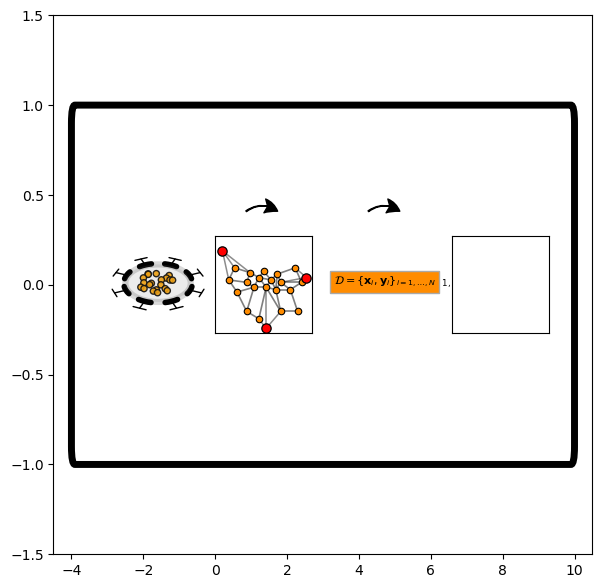

In [283]:
import matplotlib.pyplot as plt
import matplotlib.patches as ps
from matplotlib.patches import Circle, Arc
from mpl_toolkits.mplot3d import art3d
import numpy as np

def scatter_ground_and_layer(
    ax,                      # <-- pass in an existing 3D axes
    x1, y1, x2, y2,
    h=0.0,
    s1=20, s2=30,
    ground_circle_center=(0.0, 0.0),
    ground_circle_radius=0.8,
    ground_circle_alpha=0.15,

    add_electrodes=True,
    n_electrodes=8,
    electrode_radius=None,
    electrode_arc_deg=22,
    electrode_color="k",
    electrode_lw=4.0,
    electrode_z=0.0,

    add_handlebars=True,
    handle_stem_len=0.10,
    handle_bar_len=0.12,
    handle_lw=1.0,
    handle_color="k",
):
    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatter(s)
    ax.scatter(x1, y1, z1, c='orange', s=s1, alpha=0.9, edgecolors="k", zorder=5)
    # ax.scatter(x2, y2, z2, c='crimson', s=s2, alpha=0.9, edgecolors="k", zorder=6)

    # Ground circle fill
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        facecolor='gray',
        edgecolor='k',
        lw=4.5,
        zorder=4,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # Electrodes as arcs
    if add_electrodes:
        cx, cy = ground_circle_center
        R = ground_circle_radius if electrode_radius is None else electrode_radius
        sector = 360.0 / n_electrodes
        gap = max(0.0, sector - electrode_arc_deg)

        for i in range(n_electrodes):
            theta_c = i * sector
            theta1 = theta_c + gap / 2.0
            theta2 = theta1 + electrode_arc_deg

            arc = Arc(
                (cx, cy),
                width=2.1 * R,
                height=2.1 * R,
                angle=0,
                theta1=theta1,
                theta2=theta2,
                color=electrode_color,
                lw=electrode_lw,
                capstyle="round",
                zorder=10
            )
            ax.add_patch(arc)
            art3d.pathpatch_2d_to_3d(arc, z=electrode_z, zdir="z")

            if add_handlebars:
                theta_mid = np.deg2rad((theta1 + theta2) / 2.0)

                # radial stem
                x0 = cx + R * np.cos(theta_mid)
                y0 = cy + R * np.sin(theta_mid)
                x1h = cx + (R + handle_stem_len) * np.cos(theta_mid)
                y1h = cy + (R + handle_stem_len) * np.sin(theta_mid)

                ax.plot([x0, x1h], [y0, y1h], [electrode_z, electrode_z],
                        color=handle_color, lw=handle_lw, solid_capstyle="round")

                # tangential bar
                tx, ty = -np.sin(theta_mid), np.cos(theta_mid)
                half = handle_bar_len / 2.0
                xb0, yb0 = x1h - half * tx, y1h - half * ty
                xb1, yb1 = x1h + half * tx, y1h + half * ty

                ax.plot([xb0, xb1], [yb0, yb1], [electrode_z, electrode_z],
                        color=handle_color, lw=handle_lw, solid_capstyle="round")

    # Clean 3D axes look
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=35, azim=135)

    return ax


# -------------------------
# Main figure + rectangle
# -------------------------
fig, ax = plt.subplots(figsize=(7, 7))

rect_width = 8
rect_height = 2
pad = 0.5

# NEW: extend only to the right (keep left edge fixed)
extra_right = 6.0                 # room for 2 more insets
rect_left  = -0.5 * rect_width    # original left edge
rect_width_wide = rect_width + extra_right
rect_right = rect_left + rect_width_wide

ax.set_box_aspect(1)
ax.set_xlim(rect_left - pad, rect_right + pad)
ax.set_ylim(-0.5*rect_height - pad, 0.5*rect_height + pad)

rect_box = ps.FancyBboxPatch(
    xy=(rect_left, -0.5*rect_height),
    width=rect_width_wide,
    height=rect_height,
    boxstyle='round,pad=0.0,rounding_size=0.1',
    linewidth=5.0,
    fill=None
)
ax.add_patch(rect_box)

# -----------------------------------------
# Insets laid out left -> right (4 slots)
# -----------------------------------------
slots = [
    [0.04, 0.35, 0.3, 0.30],  # slot 1 (left)  -> 3D
    [0.30, 0.35, 0.18, 0.30],  # slot 2         -> graph
    [0.52, 0.35, 0.18, 0.30],  # slot 3 (reserved)
    [0.74, 0.35, 0.18, 0.30],  # slot 4 (reserved)
]

# --- slot 1: 3D inset ---
ax_3d = ax.inset_axes(slots[0], projection="3d", transform=ax.transAxes)

# --- slot 2: graph inset ---
ax_graph = ax.inset_axes(slots[1], transform=ax.transAxes)
ax_graph.set_xticks([])
ax_graph.set_yticks([])
ax_graph.set_xlim(-1., 1.)
ax_graph.set_ylim(-1., 1.)

ax_graph.set_box_aspect(1)

# --- slot 3 + 4: placeholders for future insets ---
ax_extra1 = ax.inset_axes(slots[2], transform=ax.transAxes)
ax_extra1.set_box_aspect(1)
ax_extra1.spines[:].set_visible(False)
ax_extra1.text(x=0.0, y=0.5, 
        s=r'$\mathcal{D} = \{ \mathbf{x}_i, \mathbf{y}_i \}_{i= 1, \ldots, N}$', 
        fontsize=8, 
        bbox=dict(
            boxstyle="square",
            ec="darkgray",
            fc="darkorange",
            ),
       )


ax_extra2 = ax.inset_axes(slots[3], transform=ax.transAxes)
ax_extra2.set_box_aspect(1)
for a in (ax_extra1, ax_extra2):
    a.set_xticks([]); a.set_yticks([])
    a.set_frame_on(True)   # set False if you want them invisible
    a.set_xlim(0, 1); a.set_ylim(0, 1)

# -------------------------
# Graph content (unchanged)
# -------------------------
graph_node_coords = np.array(
    [
        # core-ish cluster
        [ 0.15,  0.10],  # 0
        [-0.10,  0.15],  # 1
        [ 0.05, -0.05],  # 2
        [ 0.25, -0.10],  # 3
        [-0.20, -0.05],  # 4
        [ 0.00,  0.28],  # 5
        [ 0.28,  0.22],  # 6
        [-0.28,  0.25],  # 7
        [-0.35,  0.05],  # 8
        [ 0.35,  0.05],  # 9

        # left side / upper left
        [-0.60,  0.35],  # 10
        [-0.72,  0.10],  # 11
        [-0.55, -0.15],  # 12

        # bottom / lower left
        [-0.35, -0.55],  # 13
        [-0.10, -0.70],  # 14

        # right / upper right
        [ 0.65,  0.35],  # 15
        [ 0.78,  0.05],  # 16
        [ 0.55, -0.10],  # 17

        # bottom / lower right
        [ 0.35, -0.55],  # 18
        [ 0.70, -0.55],  # 19
    ]
)

ax_graph.scatter(
    *graph_node_coords.T,
    s=22,
    fc="darkorange",
    ec="k",
    lw=0.8,
    zorder=3
)

edges = [
    # core mesh
    (0, 1), (0, 2), (0, 3), (1, 2), (1, 4), (2, 4), (3, 2),
    (5, 0), (5, 1), (6, 0), (6, 3), (7, 1), (7, 8), (8, 4),
    (9, 3), (9, 6), (9, 17),

    # left side connections
    (10, 7), (10, 11), (11, 8), (11, 12), (12, 4), (12, 13),

    # bottom connections
    (13, 14), (14, 2), (13, 4),

    # right side connections
    (15, 6), (15, 16), (16, 9), (16, 17), (17, 3),

    # lower right connections
    (18, 3), (18, 2), (18, 19), (19, 17),
]

for i, j in edges:
    xi, yi = graph_node_coords[i]
    xj, yj = graph_node_coords[j]
    ax_graph.plot([xi, xj], [yi, yj], color="k", lw=1.2, alpha=0.5, zorder=2)

red_pts = np.array([
    [-0.85,  0.70],  # upper-left outskirts
    [ 0.88,  0.15],  # right outskirts
    [ 0.05, -0.90],  # bottom outskirts
])
ax_graph.scatter(*red_pts.T, s=45, c="red", edgecolors="k", linewidths=0.9, zorder=4)

red_to_orange = [
    (0, [10, 7, 11]),
    (1, [16, 15, 9]),
    (2, [14, 18, 2]),
]

for r_idx, orange_list in red_to_orange:
    xr, yr = red_pts[r_idx]
    for o_idx in orange_list:
        xo, yo = graph_node_coords[o_idx]
        ax_graph.plot([xr, xo], [yr, yo], color="k", lw=1.1, alpha=0.45, zorder=1)

# -------------------------
# 3D content (unchanged)
# -------------------------
rng = np.random.default_rng(42)
radius = 0.7
rs = radius * np.sqrt(rng.uniform(0, 1.0, 20))
thetas = rng.uniform(0, 2*np.pi, 20)
x1 = rs * np.cos(thetas)
y1 = rs * np.sin(thetas)
x2 = rng.uniform(-0.2, 0.2, 3)
y2 = rng.uniform(-0.2, 0.2, 3)

scatter_ground_and_layer(
    ax_3d,
    x1, y1, x2, y2,
    h=1.5,
    ground_circle_center=(0.0, 0.0),
    ground_circle_radius=radius + 0.5,
    add_electrodes=True,
    n_electrodes=8,
    electrode_arc_deg=22,
    handle_stem_len=.5,
    handle_bar_len=.5,
)

# -------------------------
# Arrows + text (adjusted for wider rectangle)
# -------------------------
style = "fancy, tail_width=0.7, head_width=10, head_length=10"
kw = dict(arrowstyle=style, color="k")

mid = 0.5 * (rect_left + rect_right)

f1 = ps.FancyArrowPatch((mid - 2.2, 0.4), (mid - 1.2, 0.4),
                        connectionstyle="arc3, rad=-.4", **kw, zorder=6)
f2 = ps.FancyArrowPatch((mid + 1.2, 0.4), (mid + 2.2, 0.4),
                        connectionstyle="arc3, rad=-.4", **kw, zorder=6)
ax.add_patch(f1)
ax.add_patch(f2)

ax.text(x=mid + 1.0, y=0.0,
        s=r'$\mathcal{D} = \{ \mathbf{x}_i, \mathbf{y}_i \}_{i= 1, \ldots, N}$',
        fontsize=9)

plt.show()


## MARKOV CHAINS (Theoretical Foundations)

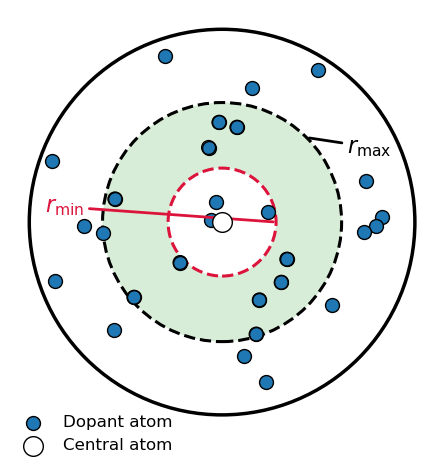

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# -----------------------------
# Parameters you can tweak
# -----------------------------
R_disk = 1.0          # radius of the semiconductor disk
r_min = 0.28          # inner neighbor radius
r_max = 0.62          # outer neighbor radius
N_atoms = 28          # number of atoms drawn (excluding central)
dopant_fraction = 0.25
seed = 7

# -----------------------------
# Helper: sample points uniformly in a disk
# -----------------------------
rng = np.random.default_rng(seed)
theta = rng.uniform(0, 2*np.pi, N_atoms)
rad = R_disk * np.sqrt(rng.uniform(0, 1, N_atoms))  # sqrt for uniform area density
x = rad * np.cos(theta)
y = rad * np.sin(theta)

# Assign atom types (host vs dopant)
is_dopant = rng.uniform(0, 1, N_atoms) < dopant_fraction

# Central atom at origin
xc, yc = 0.0, 0.0

# Determine which atoms lie in the neighbor annulus of the central atom
d = np.sqrt((x - xc)**2 + (y - yc)**2)
in_shell = (d >= r_min) & (d <= r_max)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots()

# Disk boundary
ax.add_patch(Circle((0, 0), R_disk, fill=False, lw=2.5))

# Shaded neighbor annulus: draw outer filled, then "punch out" inner with white
ax.add_patch(Circle((xc, yc), r_max, facecolor="tab:green", alpha=0.18, edgecolor="none"))
ax.add_patch(Circle((xc, yc), r_min, facecolor="white", edgecolor="none"))

# Neighbor radii (dashed)
ax.add_patch(Circle((xc, yc), r_min, fill=False, ls="--", lw=2.2, ec="crimson"))
ax.add_patch(Circle((xc, yc), r_max, fill=False, ls="--", lw=2.2, ec="black"))

# Atoms (optionally emphasize those in the shell with a ring)
host = ~is_dopant
#ax.scatter(x[host], y[host], s=100, c="tab:blue", edgecolors="k", linewidths=1.0, label="Host atom", zorder=3)
ax.scatter(x, y, s=100, c="tab:blue", edgecolors="k", linewidths=1.0, label="Dopant atom", zorder=3)

# Outline atoms that are counted as neighbors (in the annulus)
ax.scatter(x[in_shell], y[in_shell], s=100, facecolors="none", edgecolors="k", linewidths=1.0, zorder=4)

# Central atom
ax.scatter([xc], [yc], s=200, c="white", edgecolors="k", linewidths=1.0, label="Central atom", zorder=5)
#ax.text(xc, yc - 0.09, "Central atom", ha="center", va="top", fontsize=13)

# Labels for r_min and r_max (simple annotated lines)
ax.annotate(r"$r_{\min}$", xy=(r_min, 0), xytext=(-0.92, 0.05),
            arrowprops=dict(arrowstyle="-", lw=2.0, color="crimson"),
            fontsize=16, color="crimson")

ax.annotate(r"$r_{\max}$", xy=(r_max/np.sqrt(2), r_max/np.sqrt(2)),
            xytext=(0.65, 0.36),
            arrowprops=dict(arrowstyle="-", lw=2.0, color="black"),
            fontsize=16, color="black")

#ax.text(0.45, -0.02, "Neighbor shell\n(counted neighbors)", ha="left", va="center", fontsize=12)

# Styling
ax.set_aspect("equal", "box")
#ax.set_xlim(-1.15, 1.15)
#ax.set_ylim(-1.0, 1.0)
ax.axis("off")
ax.legend(
    loc="center left",
    bbox_to_anchor=(0.0, 0.0),   # just outside the right edge
    frameon=False,
    fontsize=12,
    borderaxespad=0.0
)

fig.tight_layout()
plt.savefig('min_max_distance.pdf', bbox_inches='tight')


plt.show()


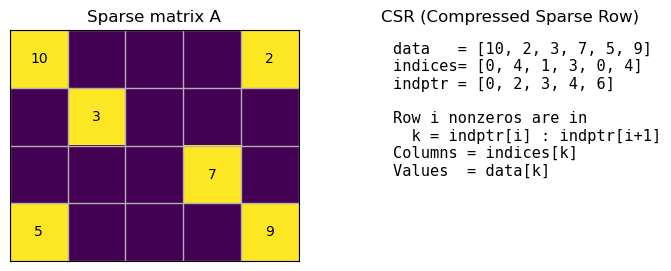

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- Example sparse matrix (4x5) ---
A = np.array([
    [10, 0, 0, 0, 2],
    [ 0, 3, 0, 0, 0],
    [ 0, 0, 0, 7, 0],
    [ 5, 0, 0, 0, 9],
], dtype=int)

# --- CSR representation (manually for clarity) ---
data   = np.array([10, 2, 3, 7, 5, 9])
indices= np.array([ 0, 4, 1, 3, 0, 4])   # column indices for each entry in data
indptr = np.array([ 0, 2, 3, 4, 6])      # row pointer: start of each row in data/indices

# --- Plot ---
fig, (axA, axC) = plt.subplots(
    1, 2, figsize=(8, 3),
    gridspec_kw=dict(width_ratios=[1.25, 1.0], wspace=0.35)
)

# Left: matrix (show sparsity + values)
axA.imshow(A != 0, interpolation="nearest", aspect="equal")
axA.set_title("Sparse matrix A")

# grid lines to show cells
axA.set_xticks(np.arange(A.shape[1]))
axA.set_yticks(np.arange(A.shape[0]))
axA.set_xticklabels([])
axA.set_yticklabels([])
axA.set_xticks(np.arange(-.5, A.shape[1], 1), minor=True)
axA.set_yticks(np.arange(-.5, A.shape[0], 1), minor=True)
axA.grid(which="minor", linewidth=1)
axA.tick_params(which="both", bottom=False, left=False)

# annotate nonzeros
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if A[i, j] != 0:
            axA.text(j, i, str(A[i, j]), ha="center", va="center")

# Right: CSR arrays as text
axC.axis("off")
axC.set_title("CSR (Compressed Sparse Row)")

csr_text = (
    f"data   = {data.tolist()}\n"
    f"indices= {indices.tolist()}\n"
    f"indptr = {indptr.tolist()}\n\n"
    "Row i nonzeros are in\n"
    "  k = indptr[i] : indptr[i+1]\n"
    "Columns = indices[k]\n"
    "Values  = data[k]"
)
axC.text(0.0, 0.95, csr_text, va="top", family="monospace", fontsize=11)

plt.show()


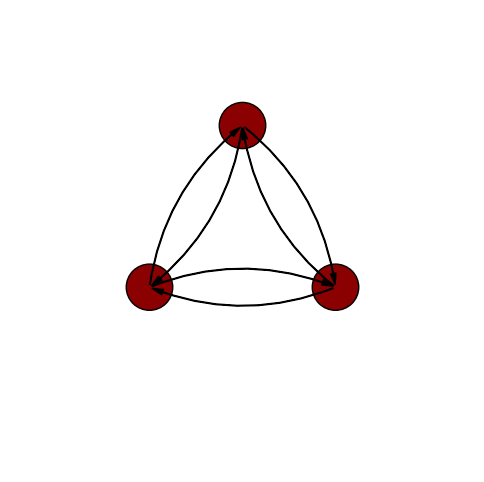

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

ax.axis("off")
c_1 = patches.Circle(xy=[0.5, 0.75], radius=0.05, edgecolor="k", facecolor="darkred")
c_2 = patches.Circle(xy=[0.3, 0.4], radius=0.05, edgecolor="k", facecolor="darkred")
c_3 = patches.Circle(xy=[0.7, 0.4], radius=0.05, edgecolor="k", facecolor="darkred")

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

a_12 = patches.FancyArrowPatch((0.3, 0.4), (0.5, 0.75), connectionstyle="arc3, rad=-.2", **kw)
a_21 = patches.FancyArrowPatch((0.5, 0.75), (0.3, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_23 = patches.FancyArrowPatch((0.5, 0.75), (0.7, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_32 = patches.FancyArrowPatch((0.7, 0.4), (0.5, 0.75), connectionstyle="arc3, rad=-.2", **kw)
a_31 = patches.FancyArrowPatch((0.7, 0.4), (0.3, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_13 = patches.FancyArrowPatch((0.3, 0.4), (0.7, 0.4), connectionstyle="arc3, rad=-.2", **kw)

ax.add_artist(c_1)
ax.add_artist(c_2)
ax.add_artist(c_3)

ax.add_artist(a_12)
ax.add_artist(a_21)
ax.add_artist(a_23)
ax.add_artist(a_32)
ax.add_artist(a_31)
ax.add_artist(a_13)

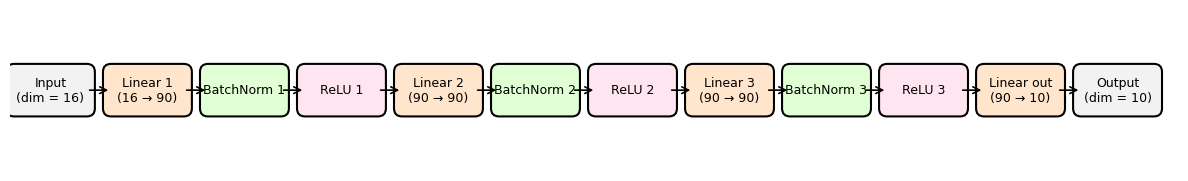

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_block(ax, center, text, width=1.8, height=0.9, facecolor="#ddeeff"):
    """
    Draw a rounded rectangle block with centered text.
    Returns the Rectangle patch.
    """
    x = center[0] - width / 2
    y = center[1] - height / 2

    rect = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.2",
        edgecolor="black",
        facecolor=facecolor,
        linewidth=1.5,
    )
    ax.add_patch(rect)
    ax.text(
        center[0],
        center[1],
        text,
        ha="center",
        va="center",
        fontsize=9,
    )
    return rect

def connect_blocks(ax, left_rect, right_rect):
    """
    Draw an arrow from the center-right of left_rect to
    the center-left of right_rect.
    """
    x1 = left_rect.get_x() + left_rect.get_width()
    y1 = left_rect.get_y() + left_rect.get_height() / 2
    x2 = right_rect.get_x()
    y2 = right_rect.get_y() + right_rect.get_height() / 2

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=12,
        linewidth=1.2,
    )
    ax.add_patch(arrow)

def draw_nn_with_batchnorm_relu(
    input_dim=16,
    hidden_dims=(90, 90, 90),
    output_dim=10,
    filename="nn_3hidden_bn_relu.pdf",
):
    """
    Draws a simple architecture diagram of an MLP with:
      - Input layer
      - 3 hidden layers
        (Linear -> BatchNorm -> ReLU)
      - Output layer

    and saves it as a PNG.
    """
    if len(hidden_dims) != 3:
        raise ValueError("This function expects exactly 3 hidden layers.")

    fig, ax = plt.subplots(figsize=(12, 3))

    x = 0.0
    y = 0.0
    dx = 2.4  # horizontal spacing between block centers

    blocks = []

    # Input block
    input_text = f"Input\n(dim = {input_dim})"
    b_in = add_block(ax, (x, y), input_text, facecolor="#f2f2f2")
    blocks.append(b_in)

    prev_dim = input_dim

    # Hidden layers: Linear -> BatchNorm -> ReLU
    for i, h in enumerate(hidden_dims, start=1):
        x += dx
        lin_text = f"Linear {i}\n({prev_dim} → {h})"
        b_lin = add_block(ax, (x, y), lin_text, facecolor="#ffe5cc")
        blocks.append(b_lin)

        x += dx
        bn_text = f"BatchNorm {i}"
        b_bn = add_block(ax, (x, y), bn_text, facecolor="#e0ffd5")
        blocks.append(b_bn)

        x += dx
        relu_text = f"ReLU {i}"
        b_relu = add_block(ax, (x, y), relu_text, facecolor="#ffe5f0")
        blocks.append(b_relu)

        prev_dim = h

    # Output block
    x += dx
    out_text = f"Output\n(dim = {output_dim})"
    b_out_lin = add_block(
        ax,
        (x, y),
        f"Linear out\n({prev_dim} → {output_dim})",
        facecolor="#ffe5cc",
    )
    blocks.append(b_out_lin)

    x += dx
    b_out = add_block(ax, (x, y), f"Output\n(dim = {output_dim})", facecolor="#f2f2f2")
    blocks.append(b_out)

    # Connect all blocks in sequence
    for left, right in zip(blocks[:-1], blocks[1:]):
        connect_blocks(ax, left, right)

    # Formatting
    ax.set_aspect("equal")
    ax.axis("off")

    # Nice limits
    ax.set_xlim(-1, x + 1.5)
    ax.set_ylim(-2, 2)

    plt.tight_layout()
    #plt.savefig(filename, dpi=300, bbox_inches="tight")
    #plt.close(fig)
    #print(f"Saved diagram to {filename}")
    plt.show()

if __name__ == "__main__":
    draw_nn_with_batchnorm_relu()


## EXPONENTIAL WAITING TIMES / MEMORYLESSNESS

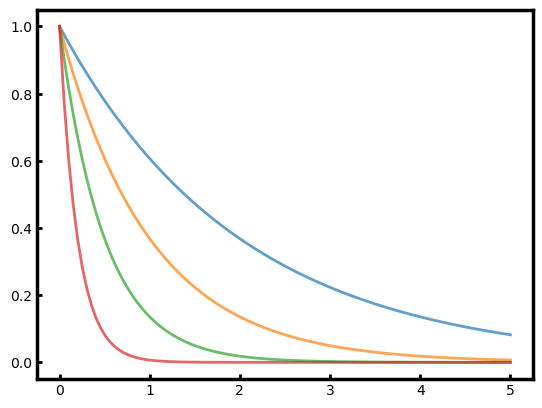

In [9]:
lambdas = [0.5, 1.0, 2.0, 5.0]
fig, ax = plt.subplots()
ax.tick_params(which="major", direction="in", width=2)
ax.spines[:].set_linewidth(2.5)
x = np.linspace(0, 5, 100)
for l in lambdas:
    ax.plot(x, np.exp(-l*x), alpha=.7, lw=2)

In [2]:
import matplotlib.pyplot as plt

## kMC STEPS UNCERTAINTY

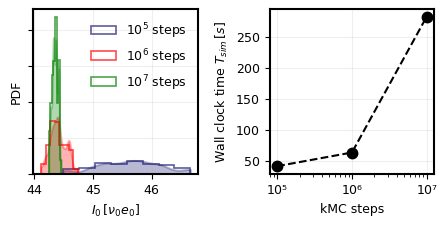

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde 

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

steps = [100_000, 1_000_000, 10_000_000]

data_100_000 = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=100000.npz')['current'] * 1e12 * 1e9
data_1_000_000 = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=1000000.npz')['current'] * 1e12 * 1e9
data_10_000_000 = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=10000000.npz')['current'] * 1e12 * 1e9

datasets = [data_100_000, data_1_000_000, data_10_000_000]
labels   = ["$10^{5}$ steps", "$10^{6}$ steps", "$10^{7}$ steps"]

bins = 8   # or try bins='fd' for automatic bin width

fig, ax = plt.subplots(ncols=2, figsize=(width_in_pt, 0.618 * height_in_pt))#, constrained_layout=True)

for a in ax:
    a.set_box_aspect(1)

color_list = [
    'midnightblue',
    'red',
    'green'
]

for i, (data, label) in enumerate(zip(datasets, labels)):
    # Histogram as probability density
    ax[0].hist(
        data,
        bins=bins,
        density=True,
        histtype='step',
        color=color_list[i],
        linewidth=1.2,
        alpha=0.7,
        label=rf"{label}"
    )

    # Continuous approximation: KDE
    kde = gaussian_kde(data)
    x_min, x_max = data.min(), data.max()
    x_grid = np.linspace(x_min, x_max, 500)
    ax[0].fill_between(
        x_grid,
        kde(x_grid),
        linewidth=1.5,
        color=color_list[i],
        alpha=.3,
        linestyle='-',
        #label=f"{label} (KDE)"
    )

ax[0].set_xlabel(r"$I_0 \, [\nu_0 e_0]$")
ax[0].set_ylabel("PDF")
ax[0].tick_params(labelleft=False)
#ax.set_title("Histogram + KDE of current for different KMC steps")
ax[0].legend(frameon=False)
ax[0].grid(alpha=0.2)
ax[0].spines[:].set_linewidth(1.5)

times_in_seconds = [41, 63, 282]
steps = [1e5, 1e6, 1e7]

ax[1].plot(steps, times_in_seconds, marker='o', ls='--', markersize=7.5, c='k')   # <-- use steps on x
ax[1].set_xscale('log')

ax[1].set_xticks(steps)
ax[1].set_xticklabels(['10⁵', '10⁶', '10⁷'])  # fix the middle label
ax[1].set_xlabel(r'kMC steps')
ax[1].set_ylabel(r'Wall clock time $T_{sim} \, [s]$')
ax[1].grid(alpha=0.2)
ax[1].spines[:].set_linewidth(1.5)
plt.savefig('kmc_steps.pdf', bbox_inches='tight')
plt.show()

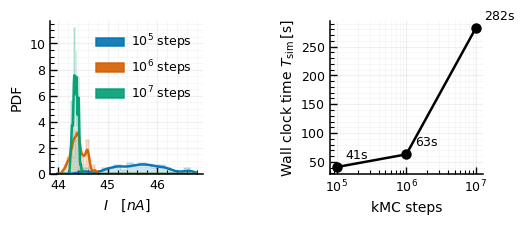

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import LogLocator, NullFormatter, AutoMinorLocator
from scipy.stats import gaussian_kde

# -------------------------
# Figure size (LaTeX textwidth)
# -------------------------
latex_txt_width = 404.02908  # pt
in_per_pt = 1 / 72.27
width_in = latex_txt_width * in_per_pt
height_in = 0.618 * width_in

# -------------------------
# Matplotlib style (paper-ready)
# -------------------------
mpl.rcParams.update({
    # Typography
    "font.size": 10.5,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Spines / lines
    "axes.linewidth": 1.1,
    "lines.linewidth": 1.8,
    "lines.markersize": 6.5,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # We’ll set grid per-axis
    "axes.grid": False,
})

# -------------------------
# Load data (your paths)
# -------------------------
data_100_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=100000.npz"
)["current"] * 1e12 * 1e9

data_1_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=1000000.npz"
)["current"] * 1e12 * 1e9

data_10_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=10000000.npz"
)["current"] * 1e12 * 1e9

datasets = [data_100_000, data_1_000_000, data_10_000_000]
labels   = [r"$10^{5}$ steps", r"$10^{6}$ steps", r"$10^{7}$ steps"]

# Colorblind-friendly palette
colors = ["#0072B2", "#D55E00", "#009E73"]

# Histogram binning: Freedman–Diaconis (often nicer than fixed small bin count)
bins = "fd"   # or set an int, e.g. 20

# -------------------------
# Build figure
# -------------------------
fig, ax = plt.subplots(
    ncols=2,
    figsize=(width_in, 0.618 * height_in),
    constrained_layout=True
)

# Make panels square
for a in ax:
    a.set_box_aspect(1)

# -------------------------
# Panel 1: histogram + KDE
# -------------------------
ax0 = ax[0]

# Use a common x-grid for all KDEs (better comparison)
xmin = min(d.min() for d in datasets)
xmax = max(d.max() for d in datasets)
xpad = 0.05 * (xmax - xmin) if xmax > xmin else 1.0
xgrid = np.linspace(xmin - xpad, xmax + xpad, 700)

for data, label, c in zip(datasets, labels, colors):
    # Soft filled histogram (density)
    ax0.hist(
        data,
        bins=bins,
        density=True,
        histtype="stepfilled",
        facecolor=c,
        edgecolor=c,
        alpha=0.18,
        linewidth=1.1,
        label=label,
    )

    # KDE line
    kde = gaussian_kde(data)  # optionally: gaussian_kde(data, bw_method=0.25)
    ax0.plot(xgrid, kde(xgrid), color=c, alpha=0.95)

ax0.set_xlabel(r"$I \quad [nA]$")
ax0.set_ylabel("PDF")

# Subtle grid + minor ticks
ax0.xaxis.set_minor_locator(AutoMinorLocator())
ax0.yaxis.set_minor_locator(AutoMinorLocator())
ax0.grid(True, which="major", alpha=0.18, linewidth=0.9)
ax0.grid(True, which="minor", alpha=0.10, linewidth=0.7)

# Clean spines
ax0.spines["top"].set_visible(False)
ax0.spines["right"].set_visible(False)

# Legend (version-safe handle access; optional alpha tweak)
leg = ax0.legend(frameon=False, handlelength=2.2, handletextpad=0.6)
handles = getattr(leg, "legend_handles", None)
if handles is None:
    handles = getattr(leg, "legendHandles", None)
if handles is None:
    handles = leg.get_lines()
for h in handles:
    try:
        h.set_alpha(0.9)
    except Exception:
        pass

# -------------------------
# Panel 2: runtime vs steps
# -------------------------
ax1 = ax[1]

times_in_seconds = [41, 63, 282]
steps = np.array([1e5, 1e6, 1e7], dtype=float)

ax1.plot(steps, times_in_seconds, marker="o", ls="-", color="black")

ax1.set_xscale("log")
ax1.set_xlabel(r"kMC steps")
ax1.set_ylabel(r"Wall clock time $T_{\mathrm{sim}} \,[\mathrm{s}]$")

# Major ticks at the three points, minor ticks between
ax1.set_xticks(steps)
ax1.set_xticklabels([r"$10^{5}$", r"$10^{6}$", r"$10^{7}$"])
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax1.xaxis.set_minor_formatter(NullFormatter())

ax1.yaxis.set_minor_locator(AutoMinorLocator())

ax1.grid(True, which="major", alpha=0.18, linewidth=0.9)
ax1.grid(True, which="minor", alpha=0.10, linewidth=0.7)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Optional point labels
for x, t in zip(steps, times_in_seconds):
    ax1.annotate(f"{t}s", (x, t), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.savefig("kmc_steps.pdf", bbox_inches="tight")
plt.show()


/tmp/ipykernel_3481805/3330654181.py:180: RuntimeWarning: invalid value encountered in divide
  var_unb = np.where(denom > 0, M2 / denom, np.nan)


[0.00603278 0.01208808 0.01812074 0.0241091  0.03009359 0.03611163
 0.0421426  0.04816099 0.05418108 0.06019297 0.06615211 0.07210115
 0.07802761 0.08396906 0.09005563 0.09604975 0.10197771 0.1079956
 0.11394469 0.11998627 0.12595224 0.13191955 0.13795311 0.14394431
 0.14995119 0.15597158 0.16206641 0.16805663 0.17404818 0.18001737
 0.18600409 0.19203705 0.19804874 0.2039946  0.21001113 0.21602029
 0.22201731 0.22797508 0.23398555 0.24000547 0.24603411 0.25208714
 0.2580863  0.26411479 0.2700994  0.27614504 0.28207269 0.2880977
 0.29415717 0.30010643 0.30620804 0.31216073 0.31810749 0.32418762
 0.33020651 0.33614774 0.3420801  0.3481203  0.35416301 0.36015571
 0.36614737 0.37226466 0.37827073 0.3842821  0.39033974 0.3963411
 0.40239828 0.40836609 0.41443171 0.42047076 0.42646358 0.43244037
 0.43844459 0.44450649 0.45043374 0.45646179 0.46248166 0.46850098
 0.47462294 0.48070806 0.48666209 0.49261736 0.49857926 0.5045549
 0.51055744 0.5166134  0.5226289  0.52864591 0.53462445 0.54068862

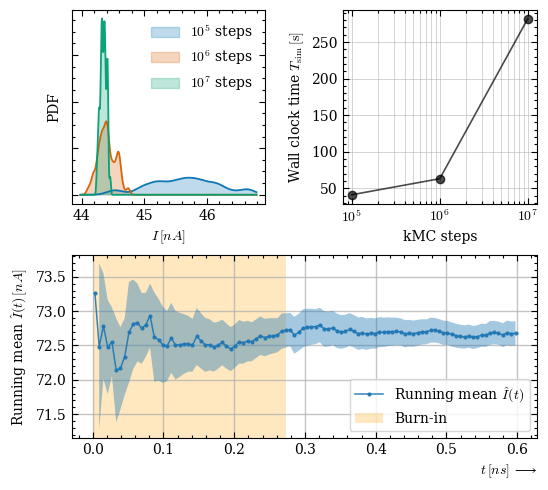

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter, AutoMinorLocator
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

# -------------------------
# Figure size (LaTeX textwidth)
# -------------------------
latex_txt_width = 455.2441  # pt
in_per_pt = 1 / 72.27
width_in = latex_txt_width * in_per_pt
height_in = 1.05 * width_in

# -------------------------
# Helper: ticks on all sides + minor ticks
# -------------------------
def style_ax(ax, logx=False, logy=False):
    for s in ax.spines.values():
        s.set_visible(True)
    ax.set_facecolor("w")

    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax.tick_params(which="major", length=4.0, width=0.8)
    ax.tick_params(which="minor", length=2.5, width=0.8)

    ax.xaxis.set_ticks_position("both")
    ax.yaxis.set_ticks_position("both")

    if not logx:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if not logy:
        ax.yaxis.set_minor_locator(AutoMinorLocator())

    ax.minorticks_on()

# -------------------------
# Load data (your paths)
# -------------------------
data_100_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=100000.npz"
)["current"] * 1e12 * 1e9

data_1_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=1000000.npz"
)["current"] * 1e12 * 1e9

data_10_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=10000000.npz"
)["current"] * 1e12 * 1e9

sem_100_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=100000.npz"
)["sem"] * 1e12 * 1e9

sem_1_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=1000000.npz"
)["sem"] * 1e12 * 1e9

sem_10_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=10000000.npz"
)["sem"] * 1e12 * 1e9

datasets = [data_100_000, data_1_000_000, data_10_000_000]
labels   = [r"$10^{5}$ steps", r"$10^{6}$ steps", r"$10^{7}$ steps"]
colors   = ["#0072B2", "#D55E00", "#009E73"]

# -------------------------
# Build combined figure: [[A,B],[C,C]]
# -------------------------
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[1.0, 0.7], hspace=0.08, wspace=0.4)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, :])

axA.set_box_aspect(1)
axB.set_box_aspect(1)

style_ax(axA)
style_ax(axB, logx=True)
style_ax(axC)

# -------------------------
# Panel A: KDE only + filled area under curve (legend uses PATCHES)
# -------------------------
xmin = min(d.min() for d in datasets)
xmax = max(d.max() for d in datasets)
xpad = 0.05 * (xmax - xmin) if xmax > xmin else 1.0
xgrid = np.linspace(xmin - xpad, xmax + xpad, 700)

fill_alpha = 0.25

for data, c in zip(datasets, colors):
    kde = gaussian_kde(data)
    y = kde(xgrid)
    axA.fill_between(xgrid, 0.0, y, color=c, alpha=fill_alpha, linewidth=0.0, zorder=1)
    axA.plot(xgrid, y, color=c, alpha=0.95, linewidth=1.3, zorder=2)  # no label here

# Legend handles as shaded patches (not lines)
legend_handles = [
    Patch(facecolor=c, edgecolor=c, alpha=fill_alpha, label=lab)
    for c, lab in zip(colors, labels)
]
axA.legend(handles=legend_handles, frameon=False, loc="best")

axA.set_xlabel(r"$I \, [nA]$")
axA.set_ylabel("PDF")
axA.tick_params(labelleft=False)
#axA.grid(alpha=.75, lw=1, which='major')
#axA.grid(alpha=.75, lw=0.2, which='minor')

# -------------------------
# Panel B: runtime vs steps
# -------------------------
times_in_seconds = [41, 63, 282]
steps = np.array([1e5, 1e6, 1e7], dtype=float)

axB.plot(steps, times_in_seconds, marker="o", ls="-", lw=1.2, alpha=.7, color="black")
axB.set_xscale("log")
axB.set_xlabel(r"kMC steps")
axB.set_ylabel(r"Wall clock time $T_{\mathrm{sim}} \,[\mathrm{s}]$")

axB.set_xticks(steps)
axB.set_xticklabels([r"$10^{5}$", r"$10^{6}$", r"$10^{7}$"])

axB.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
axB.xaxis.set_minor_formatter(NullFormatter())
axB.yaxis.set_minor_locator(AutoMinorLocator())
axB.grid(alpha=.75, lw=0.5, which='major')
axB.grid(alpha=.75, lw=0.5, which='minor', axis='x')

# -------------------------
# Panel C: burn-in running means
# -------------------------

for i in range(1):
    data = np.loadtxt(
        f"/gpfs/bwfor/work/ws/hd_gy283-my_data/burnins_ed=0.01_a=20_steps=10e7/burnin_0.txt",
        skiprows=1
    )

    ts, te, tmid, I = data.T

    tmid = tmid * 1e-6
    #tmid = np.linspace(0, 100, 100)
    dt = np.cumsum((te - ts) * 1e-6)
    
    e0 = 1.602e-19
    #print(dt.shape)
    # --- running weighted mean (what you already do) ---
    W  = np.cumsum(dt)
    S1 = np.cumsum(dt * I)
    I_run = S1 / W

    # --- running "error bar": SE of the weighted mean ---
    W2 = np.cumsum(dt * dt)
    S2 = np.cumsum(dt * I * I)

    M2 = S2 - (S1 * S1) / W
    denom = W - (W2 / W)                      # "effective dof" term
    var_unb = np.where(denom > 0, M2 / denom, np.nan)
    se_run = np.sqrt(var_unb * (W2 / (W * W)))

    # scale BOTH mean and se the same way
    scale = 1e12 * 1e9 * e0
    I_run *= scale
    se_run *= scale

    label = r"Running mean $\hat I(t)$" if i == 0 else "_nolegend_"
    axC.plot(tmid, I_run, linewidth=1.1, marker="o", markersize=2, alpha=0.9, label=label)

    # shaded 1-sigma band (use 1.96*se_run for ~95% if you want)
    if i == 0:  # only show band once to avoid clutter; remove if you want all
        axC.fill_between(tmid, I_run - 1.96*se_run, I_run + 1.96*se_run, alpha=0.4, linewidth=0, zorder=5)
    #axC.fill_between(tmid, I_run - se_run, I_run + se_run, alpha=0.2, linewidth=0)

    axC.grid(alpha=.75, lw=1, which='major')
    #axC.grid(alpha=.75, lw=0.2, which='minor')

print(dt)
axC.axvspan(xmin=0.0, xmax=tmid[45], alpha=.25, zorder=-1, fc='orange', label='Burn-in')
axC.set_xlabel(r"$t \, [ns] \, \longrightarrow$", loc="right")
#axC.set_xlabel('bins')
axC.set_ylabel(r"Running mean $\hat{I}(t)\,[nA]$")
#axC.tick_params(labelbottom=False)
axC.legend(frameon=True, loc="best")

plt.savefig("kmc_steps_wall_clock_burnin.pdf", bbox_inches="tight")
plt.show()


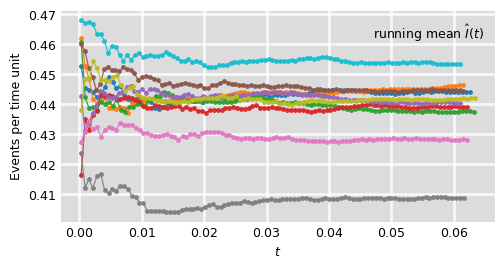

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# -------------------------
# LaTeX geometry you will use
# -------------------------
wfrac = 0.49  # <-- match your LaTeX: subfigure width for A and B (e.g. 0.49\textwidth)

latex_txt_width = 404.02908  # pt
in_per_pt = 1 / 72.27
textwidth_in = latex_txt_width * in_per_pt

# Make the exported PDFs have the SAME aspect ratios as in LaTeX.
# Absolute inches don't matter; aspect ratio does.
A_size = (wfrac * textwidth_in, wfrac * textwidth_in)  # square
B_size = (wfrac * textwidth_in, wfrac * textwidth_in)  # square
C_size = (1.00 * textwidth_in, wfrac * textwidth_in)   # wide, height matches A/B when scaled in LaTeX

# -------------------------
# Style: bottom plot (NO tick bars, ONLY major grid)
# -------------------------
def bottom_style_major_only(ax):
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_facecolor("gainsboro")
    ax.grid(True, which="major", color="w", linewidth=2.0, alpha=0.75)
    ax.minorticks_off()
    ax.tick_params(axis="both", which="both", length=0.0)

# -------------------------
# Load data
# -------------------------
data_100_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=100000.npz"
)["current"] * 1e12 * 1e9

data_1_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=1000000.npz"
)["current"] * 1e12 * 1e9

data_10_000_000 = np.load(
    "/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/kmc_steps_histograms/steps=10000000.npz"
)["current"] * 1e12 * 1e9

datasets = [data_100_000, data_1_000_000, data_10_000_000]
labels   = [r"$10^{5}$ steps", r"$10^{6}$ steps", r"$10^{7}$ steps"]
colors   = ["#0072B2", "#D55E00", "#009E73"]
bins     = "fd"

# Common KDE grid
xmin = min(d.min() for d in datasets)
xmax = max(d.max() for d in datasets)
xpad = 0.05 * (xmax - xmin) if xmax > xmin else 1.0
xgrid = np.linspace(xmin - xpad, xmax + xpad, 700)

# -------------------------
# A: histogram + KDE
# -------------------------
figA, axA = plt.subplots(figsize=A_size)
bottom_style_major_only(axA)

for data, label, c in zip(datasets, labels, colors):
    axA.hist(
        data, bins=bins, density=True,
        histtype="stepfilled", facecolor=c, edgecolor=c,
        alpha=0.22, linewidth=1.1, label=label,
    )
    kde = gaussian_kde(data)
    axA.plot(xgrid, kde(xgrid), color=c, alpha=0.95, linewidth=1.3)

axA.set_xlabel(r"$I \quad [nA]$")
axA.set_ylabel("PDF")
axA.legend(frameon=False, loc="best")

figA.savefig("A.pdf", bbox_inches="tight", pad_inches=0.02)
plt.close(figA)

# -------------------------
# B: runtime vs steps
# -------------------------
figB, axB = plt.subplots(figsize=B_size)
bottom_style_major_only(axB)

times_in_seconds = [41, 63, 282]
steps = np.array([1e5, 1e6, 1e7], dtype=float)

axB.plot(steps, times_in_seconds, marker="o", ls="-", color="black")
axB.set_xscale("log")
axB.set_xlabel(r"kMC steps")
axB.set_ylabel(r"Wall clock time $T_{\mathrm{sim}} \,[\mathrm{s}]$")

axB.set_xticks(steps)
axB.set_xticklabels([r"$10^{5}$", r"$10^{6}$", r"$10^{7}$"])

# Ensure NO tick bars on log axis (apply AFTER setting scale/ticks)
axB.minorticks_off()
axB.tick_params(axis="both", which="both", length=0.0)

for x, t in zip(steps, times_in_seconds):
    axB.annotate(f"{t}s", (x, t), textcoords="offset points", xytext=(6, 6), fontsize=9)

figB.savefig("B.pdf", bbox_inches="tight", pad_inches=0.02)
plt.close(figB)

# -------------------------
# C: burn-in running means
# -------------------------
figC, axC = plt.subplots(figsize=C_size)
bottom_style_major_only(axC)

for i in range(10):
    data = np.loadtxt(
        f"/gpfs/bwfor/work/ws/hd_gy283-my_data/burnins_ed=0.01/burnin_{i}.txt",
        skiprows=1
    )
    ts, te, tmid, I = data.T
    dt = te - ts
    I_run = np.cumsum(I * dt) / np.cumsum(dt)
    tmid = tmid * 1e-6

    axC.plot(tmid, I_run, linewidth=0.9, marker="o", markersize=2.5, alpha=0.9)

axC.set_xlabel(r"$t$")
axC.set_ylabel("Events per time unit")

# text-only legend (no marker/line)
dummy = Line2D([], [], linestyle="none", marker=None)
axC.legend([dummy], [r"running mean $\hat I(t)$"], frameon=False, handlelength=0, handletextpad=0)

figC.savefig("C.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()


## DEVICE SIMULATION / CURRENT DISTRIBUTION

4.4.0
11.8
2.7.0+cu118
2.6.1


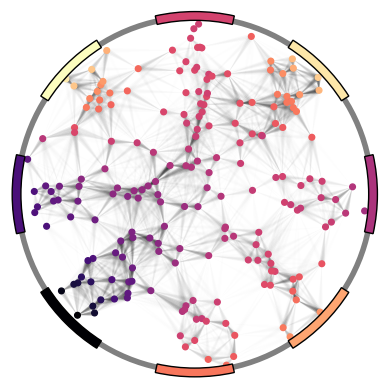

In [81]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
import torch_geometric
import pandas as pd
import torch.nn as nn
import optuna

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch, os

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri

from torch_geometric.data import Data
from torch_geometric.data import HeteroData
from scipy.optimize import curve_fit
from sm import NeuralNet
from utils import create_dopant_configuration, current_distribution

print(torch.version.cuda)
print(torch.__version__)
print(torch_geometric.__version__)

fig, ax = plt.subplots(ncols=1)
ax.set_box_aspect(1)
device_data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/dist_device_0_v={1.0}_radial.npz')
#print(device_data.files)
#print(device_data['event_matrix'].sum())

current_distribution(ax, None, device_data, 0.0)   

#ax[1].set_box_aspect(1)

plt.show()

## SURROGATE MODEL TRAINING

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d import art3d
import numpy as np
from utils import pred_vs_true

## DEVICE (3D)

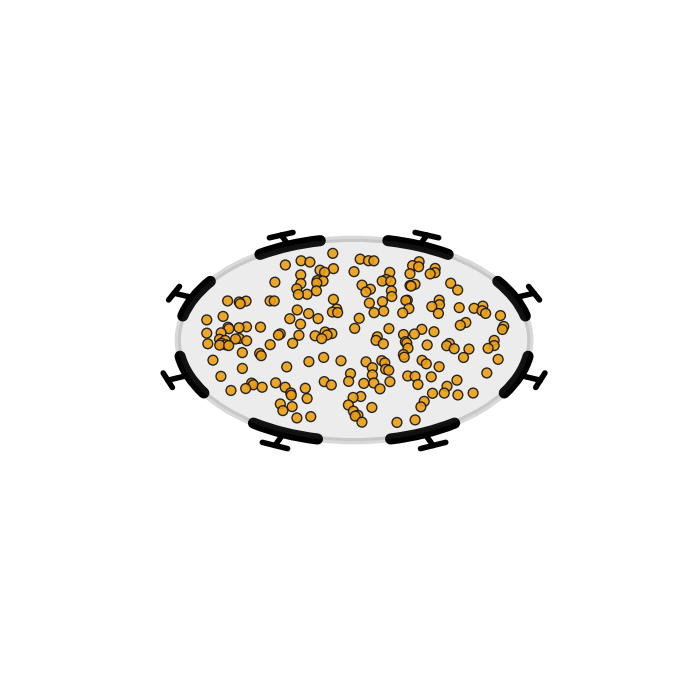

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc
from mpl_toolkits.mplot3d import art3d
import numpy as np


def scatter_ground_and_layer(
    x1, y1, x2, y2,
    h=0.0,
    c1=None, c2=None,
    s1=50, s2=60,
    show_shadows=False,
    show_ground_plane=False,
    ground_circle_center=(0.5, 0.5),
    ground_circle_radius=0.6,
    ground_circle_color="lightblue",
    ground_circle_alpha=0.15,

    # --- electrodes ---
    add_electrodes=True,
    n_electrodes=8,
    electrode_radius=None,          # if None, uses ground_circle_radius
    electrode_arc_deg=22,           # arc length (degrees) per electrode
    electrode_color="k",
    electrode_lw=8.0,
    electrode_z=0.0,              # tiny lift to avoid z-fighting

    # --- handlebars ---
    add_handlebars=True,
    handle_stem_len=0.10,           # radial stem length
    handle_bar_len=0.12,            # tangential bar total length
    handle_lw=4.0,
    handle_color="k",
):
    """
    Plot two scatters in 3D: one on the ground (z=0) and one at height h.
    Adds an optional circle on the ground plane.
    Adds optional electrode arcs + handlebars on the circle boundary.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatter(s)
    ax.scatter(x1, y1, z1, c='orange', s=s1, alpha=0.9, edgecolors="k", zorder=5)

    # ---- ground circle fill ----
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        facecolor='gray',
        edgecolor='k',
        lw=4.5,
        zorder=4,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # ---- electrodes as separated arcs on boundary ----
    if add_electrodes:
        cx, cy = ground_circle_center
        R = ground_circle_radius if electrode_radius is None else electrode_radius

        sector = 360.0 / n_electrodes
        gap = max(0.0, sector - electrode_arc_deg)  # leftover angle becomes gap

        for i in range(n_electrodes):
            # Center of this electrode in degrees
            theta_c = i * sector

            # Arc start/end (leave half the gap on each side)
            theta1 = theta_c + gap / 2.0
            theta2 = theta1 + electrode_arc_deg

            # Arc patch (2D), then lifted into 3D
            arc = Arc(
                (cx, cy),
                width=2 * R,
                height=2 * R,
                angle=0,
                theta1=theta1,
                theta2=theta2,
                color=electrode_color,
                lw=electrode_lw,
                capstyle="round",
                zorder=10
            )
            ax.add_patch(arc)
            art3d.pathpatch_2d_to_3d(arc, z=electrode_z, zdir="z")

            # ---- handlebar: small radial stem + tangential bar at the end ----
            if add_handlebars:
                # midpoint angle of this electrode (radians)
                theta_mid = np.deg2rad((theta1 + theta2) / 2.0)

                # radial stem from R to R + stem
                x0 = cx + R * np.cos(theta_mid)
                y0 = cy + R * np.sin(theta_mid)
                x1h = cx + (R + handle_stem_len) * np.cos(theta_mid)
                y1h = cy + (R + handle_stem_len) * np.sin(theta_mid)

                ax.plot(
                    [x0, x1h], [y0, y1h], [electrode_z, electrode_z],
                    color=handle_color, lw=handle_lw, solid_capstyle="round"
                )

                # tangential bar centered at (x1h, y1h)
                # tangent unit vector = (-sin, cos)
                tx = -np.sin(theta_mid)
                ty =  np.cos(theta_mid)
                half = handle_bar_len / 2.0

                xb0 = x1h - half * tx
                yb0 = y1h - half * ty
                xb1 = x1h + half * tx
                yb1 = y1h + half * ty

                ax.plot(
                    [xb0, xb1], [yb0, yb1], [electrode_z, electrode_z],
                    color=handle_color, lw=handle_lw, solid_capstyle="round"
                )

    # Optional: translucent ground plane
    if show_ground_plane:
        xmin, xmax = np.min([np.min(x1), np.min(x2)]), np.max([np.max(x1), np.max(x2)])
        ymin, ymax = np.min([np.min(y1), np.min(y2)]), np.max([np.max(y1), np.max(y2)])
        Xp, Yp = np.meshgrid(np.linspace(xmin, xmax, 2), np.linspace(ymin, ymax, 2))
        Zp = np.zeros_like(Xp)
        ax.plot_surface(Xp, Yp, Zp, alpha=0.08, rstride=1, cstride=1, linewidth=0)

    # Clean up axes
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=35, azim=135)

    # If you have no labeled artists, legend will warn; you can remove this line if you want:
    # ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


# --- Example usage ---
if __name__ == "__main__":
    rng = np.random.default_rng(42)

    radius = 0.7
    rs = radius * np.sqrt(rng.uniform(0, 1.0, 200))
    thetas = rng.uniform(0, 2*np.pi, 200)

    x1 = rs * np.cos(thetas)
    y1 = rs * np.sin(thetas)

    x2 = rng.uniform(0.2, 0.8, 3)
    y2 = rng.uniform(0.2, 0.8, 3)

    scatter_ground_and_layer(
        x1, y1, x2, y2,
        h=1.5,
        show_ground_plane=False,
        ground_circle_center=(0.0, 0.0),
        ground_circle_radius=radius + 0.1,

        add_electrodes=True,
        n_electrodes=8,
        electrode_arc_deg=22,
        handle_stem_len=0.10,
        handle_bar_len=0.12,
    )


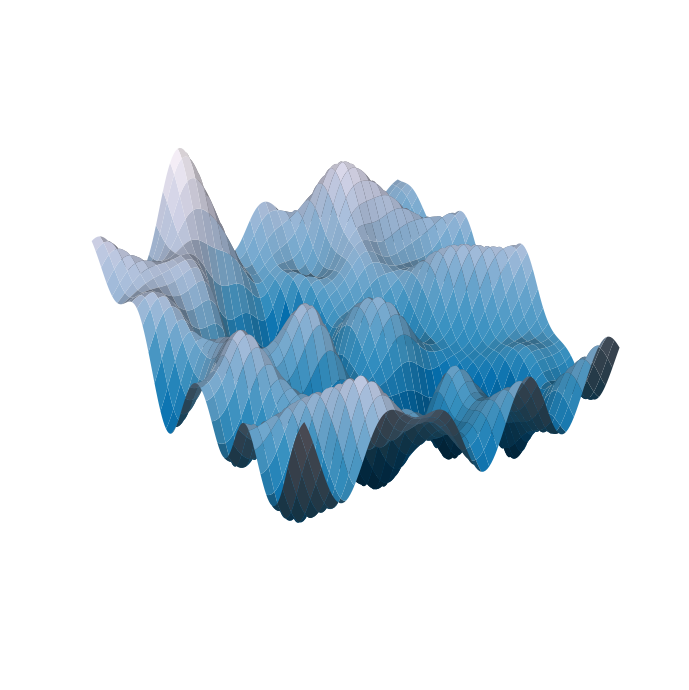

In [54]:
import numpy as np
import matplotlib.pyplot as plt


def irregular_pes(X, Y, seed=11, n_bumps=22):
    rng = np.random.default_rng(seed)
    Z = np.zeros_like(X)

    # Random Gaussian bumps
    for _ in range(n_bumps):
        x0 = rng.uniform(X.min(), X.max())
        y0 = rng.uniform(Y.min(), Y.max())
        amp = rng.uniform(-1.3, 1.3)
        sx = rng.uniform(0.18, 0.85)
        sy = rng.uniform(0.18, 0.85)
        Z += amp * np.exp(-((X - x0) ** 2 / (2 * sx ** 2) + (Y - y0) ** 2 / (2 * sy ** 2)))

    # Random ripples
    for _ in range(10):
        kx = rng.integers(1, 6)
        ky = rng.integers(1, 6)
        phase = rng.uniform(0, 2 * np.pi)
        amp = rng.uniform(0.05, 0.28)
        Z += amp * np.sin(kx * X + ky * Y + phase)

    # Gentle bowl
    Z += 0.06 * (X ** 2 + Y ** 2)

    # Normalize
    Z = (Z - Z.mean()) / (Z.std() + 1e-12)
    return Z


def plot_rect_pes_with_center_ball(
    xlim=(-2.6, 2.6),
    ylim=(-2.6, 2.6),
    n=160,
    seed=11,
    ball_radius=1.0,
    ball_resolution=120,
    elev=32,
    azim=235,
    cmap="PuBu_r",
    mesh_stride=4,         # bigger -> fewer surface lines
    mesh_lw=0.45,          # surface line thickness
    mesh_alpha=0.35,       # surface line transparency
):
    x = np.linspace(*xlim, n)
    y = np.linspace(*ylim, n)
    X, Y = np.meshgrid(x, y)
    Z = irregular_pes(X, Y, seed=seed)

    # ---- ball at the middle (x=0, y=0), touching the surface ----
    x0, y0 = 0.0, 0.0
    z_surface = float(irregular_pes(np.array([[x0]]), np.array([[y0]]), seed=seed)[0, 0])
    zc = z_surface + ball_radius  # center so bottom touches surface

    # Sphere mesh
    u = np.linspace(0, 2 * np.pi, ball_resolution)
    v = np.linspace(0, np.pi, ball_resolution)
    uu, vv = np.meshgrid(u, v)

    xs = ball_radius * np.cos(uu) * np.sin(vv) + x0
    ys = ball_radius * np.sin(uu) * np.sin(vv) + y0
    zs = ball_radius * np.cos(vv) + zc

    # ---- Plot ----
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # surface colors
    Zn = (Z - Z.min()) / (Z.max() - Z.min() + 1e-12)
    facecols = getattr(plt.cm, cmap)(Zn)

    # --- PES with surface "grid" lines ON ---
    ax.plot_surface(
        X, Y, Z,
        facecolors=facecols,
        rstride=mesh_stride,
        cstride=mesh_stride,
        linewidth=mesh_lw,
        edgecolor=(0, 0, 0, 0.0),  # RGBA: black with alpha
        antialiased=True,
        shade=True,
    )

    # Ball (no lines)
    ax.plot_surface(
        xs, ys, zs,
        color="white",
        linewidth=0,
        edgecolor="none",
        antialiased=False,
        shade=False,
    )

    # keep axes off (optional; remove these 2 lines if you want axes/ticks)
    ax.set_axis_off()
    ax.grid(False)

    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.savefig('pes_example.pdf', bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    plot_rect_pes_with_center_ball(seed=11, ball_radius=1.0)

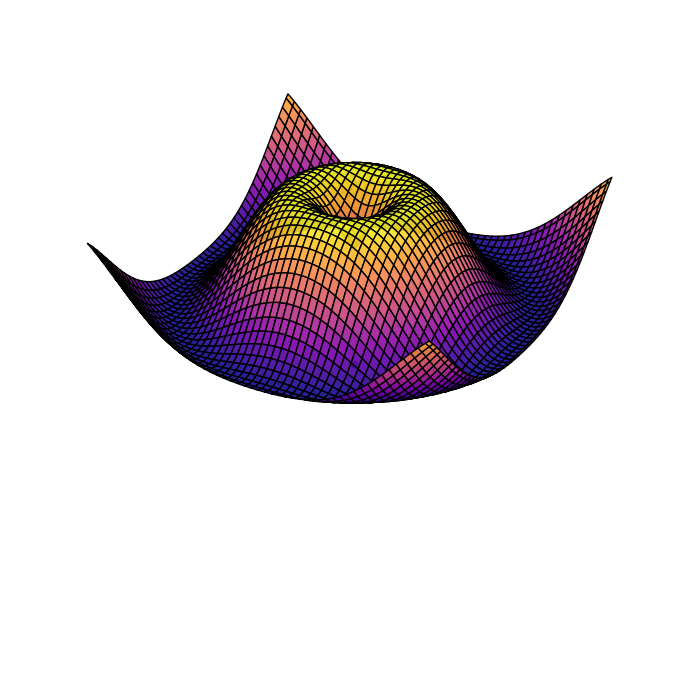

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Create figure and 3D axes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot 2D heatmap on the ground
ground = ax.scatter(0, 0)

# 2. Plot 3D surface above the ground
surf = ax.plot_surface(X, Y, Z + 2, cmap='plasma', edgecolor='k', alpha=0.9)

# 3. Disable grid, ticks, and axes
ax.grid(False)                 # Disable grid
ax.set_axis_off()              # Hide axes completely
ax.xaxis.set_visible(False)    # Hide x-axis
ax.yaxis.set_visible(False)    # Hide y-axis
ax.zaxis.set_visible(False)    # Hide z-axis

# Set limits so the figure looks balanced
ax.set_zlim(-2, 3)

plt.tight_layout()
plt.show()


## Energy Barriers

(-1.0, 1.0, -1.0, 1.0)

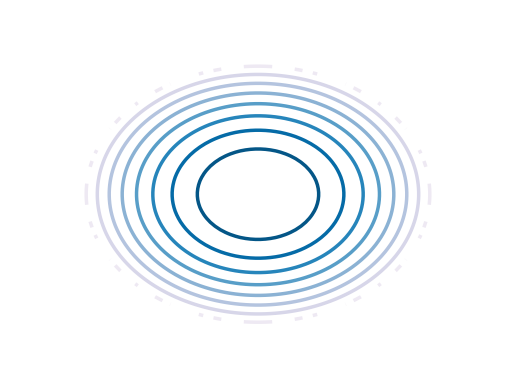

In [58]:
import numpy as np
import matplotlib.pyplot as plt
N = 100
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)

xi, yi = np.meshgrid(x, y)
Z = xi**2 + yi**2
r1 = 0.7
mask_Z = xi**2 + yi**2 <= r1**2

zi = np.where(mask_Z, Z, np.nan)


fig, ax1 = plt.subplots()
ax1.contour(xi, yi, zi, levels=8, cmap="PuBu_r", linewidths=2.5)
ax1.axis("off")

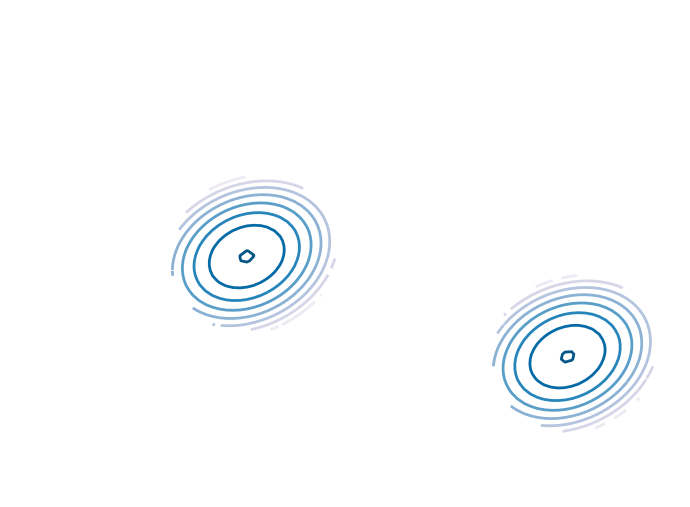

In [97]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(-4, 7, N)  # extended range to fit second well
y = np.linspace(-4, 4, N)
xi, yi = np.meshgrid(x, y)

# ---- parameters ----
theta = np.deg2rad(25)   # rotation angle
ax_scale = 1.0           # ellipticity along rotated x'
ay_scale = 0.75          # ellipticity along rotated y'
tilt = 0.25              # small linear term to break symmetry
rx, ry = 1.4, 1.3        # ellipse radii
shift_x2 = 4.5  
shift_y2 = 2.0
# horizontal shift for second well
# ---------------------

# ---- FIRST WELL (centered at origin) ----
Xr1 =  xi*np.cos(theta) + yi*np.sin(theta)
Yr1 = -xi*np.sin(theta) + yi*np.cos(theta)

Z1 = (Xr1/ax_scale)**2 + (Yr1/ay_scale)**2 + tilt*Xr1
mask_Z1 = (Xr1/rx)**2 + (Yr1/ry)**2 <= 1.0
z1i = np.where(mask_Z1, Z1, np.nan)

# ---- SECOND WELL (shifted to the right) ----
xi2 = xi - shift_x2  # shift x-coordinates BEFORE rotation
yi2 = yi + shif_y2

Xr2 =  xi2*np.cos(theta) + yi*np.sin(theta)
Yr2 = -xi2*np.sin(theta) + yi2*np.cos(theta)

Z2 = (Xr2/ax_scale)**2 + (Yr2/ay_scale)**2 + tilt*Xr2
mask_Z2 = (Xr2/rx)**2 + (Yr2/ry)**2 <= 1.0
z2i = np.where(mask_Z2, Z2, np.nan)

# ---- PLOT ----
fig, ax1 = plt.subplots(figsize=(7, 8))

# First well
ax1.contour(xi, yi, z1i, levels=8, cmap="PuBu_r", linewidths=2)
ax1.contour(xi, yi, z2i, levels=8, cmap="PuBu_r", linewidths=2)
ax1.set_aspect("equal", adjustable="box")
ax1.axis("off")

plt.tight_layout()
plt.show()


/tmp/ipykernel_964276/3797561503.py:46: RuntimeWarning: All-NaN slice encountered
  Z = np.nanmin(np.array([Z1, Z2, Z3]), axis=0)


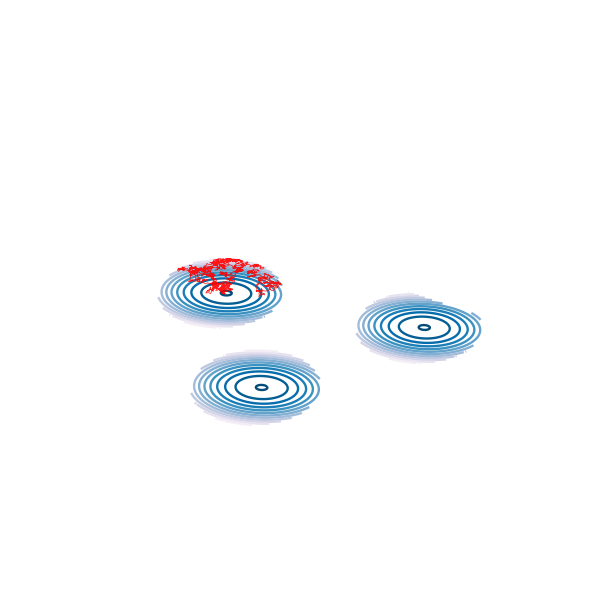

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grid
N = 250
x = np.linspace(-2.5, 6, N)
y = np.linspace(-1, 5, N)
xi, yi = np.meshgrid(x, y)

# ---- parameters ----
theta = np.deg2rad(20)   # rotation angle for all wells
ax_scale = 1.0           # ellipticity along rotated x'
ay_scale = 0.7           # ellipticity along rotated y'
tilt = 0.25              # asymmetry term
rx, ry = 1.4, 1.3        # ellipse radii

# Well positions -> forms a non-equilateral triangle
center1 = (0.0, 0.0)     # bottom-left well
center2 = (4.5, 1.0)     # bottom-right well
center3 = (2.0, 3.5)     # top well
# ---------------------

def potential_well(xi, yi, x0, y0, theta):
    """Generate an elliptical rotated potential well centered at (x0, y0)."""
    Xs = xi - x0
    Ys = yi - y0

    # Rotate coordinates
    Xr =  Xs*np.cos(theta) + Ys*np.sin(theta)
    Yr = -Xs-*np.sin(theta) + Ys*np.cos(theta)

    # Elliptical potential + asymmetry
    Z = (Xr/ax_scale)**2 + (Yr/ay_scale)**2 + tilt*Xr

    # Mask outside elliptical boundary
    mask = (Xr/rx)**2 + (Yr/ry)**2 <= 1.0
    return np.where(mask, Z, np.nan)

# Compute three separate wells
Z1 = potential_well(xi, yi, *center1, theta)
Z2 = potential_well(xi, yi, *center2, theta)
Z3 = potential_well(xi, yi, *center3, theta)

# Combine wells: take minimum potential wherever they overlap
Z = np.nanmin(np.array([Z1, Z2, Z3]), axis=0)

# ---- PLOT 3D CONTOUR PROJECTION ----
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

# Contour projections on XY-plane
ax.contour(
    xi, yi, Z,
    levels=12,
    cmap="PuBu_r",
    linewidths=1.7,
    offset=np.nanmin(Z) - 0.5
)

# Labels & view
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Potential")

# Better aspect ratio
ax.set_box_aspect([1.6, 1.2, 0.6])

# Set camera angle
ax.view_init(elev=35, azim=120)

# Cleaner look
ax.axis("off")

# --- Random trajectories inside the contour regions ---

# The same Z offset you used for contour projection
z_offset = np.nanmin(Z) - 0.5

# Precompute some helpers
valid = np.isfinite(Z)                # True where you're "inside"
dy = y[1] - y[0]
dx = x[1] - x[0]
Ny, Nx = valid.shape

def inside(xp, yp):
    """Return True if (xp, yp) lies on a valid (non-NaN) cell of Z."""
    j = int(round((xp - x[0]) / dx))  # column index in xi (x axis)
    i = int(round((yp - y[0]) / dy))  # row index in yi (y axis)
    if 0 <= i < Ny and 0 <= j < Nx:
        return valid[i, j]
    return False

def random_start():
    """Pick a random valid starting point from the grid."""
    # Sample indices from the mask
    ii, jj = np.where(valid)
    k = np.random.randint(0, len(ii))
    return x[jj[k]], y[ii[k]]

def random_walk(n_steps=800, step=0.8, max_tries=20):
    """Generate a single bounded random walk that stays inside the mask."""
    xp, yp = random_start()
    xs = [xp]; ys = [yp]
    for _ in range(n_steps):
        # Try a few random directions until one stays inside
        accepted = False
        for _ in range(max_tries):
            ang = np.random.uniform(0, 2*np.pi)
            xn = xp + step*np.cos(ang)
            yn = yp + step*np.sin(ang)
            if inside(xn, yn):
                xp, yp = xn, yn
                xs.append(xp); ys.append(yp)
                accepted = True
                break
        if not accepted:
            # If stuck, restart somewhere else inside
            xp, yp = random_start()
            xs.append(xp); ys.append(yp)
    return np.array(xs), np.array(ys)

# Generate and plot a few trajectories
num_paths = 1
for _ in range(num_paths):
    xs, ys = random_walk(n_steps=1200, step=0.06)
    ax.plot(xs, ys, zs=z_offset, c="r", zdir='z', lw=0.5, alpha=0.9, zorder=3)

# (Everything else the same; your contour + axis settings remain)


plt.tight_layout()

## Surrogate Models

['current', 'currentStd', 'sem', 'control', 'inputIdx', 'outputIdx']
[-9.99999e+02 -9.99999e+02  1.50000e+00  1.10000e+00 -2.00000e-01
 -9.00000e-01  3.00000e-01 -6.00000e-01]
tensor([[-1.5000,  1.5000,  1.1000, -0.2000, -0.9000,  0.3000, -0.6000]])


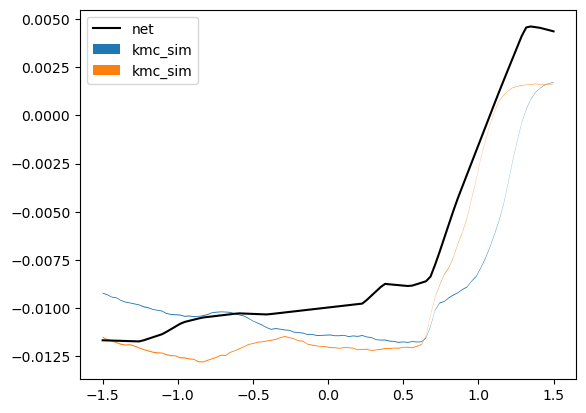

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from sm import NeuralNet

state_dict_uni = torch.load(f"/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_uni_n_a=50_1e7.pth", map_location="cpu", weights_only=False)
state_dict_vMB = torch.load(f"/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_1e7.pth", map_location="cpu", weights_only=False)

args_uni = state_dict_uni['args']
args = state_dict_vMB['args']

net_uni = NeuralNet(state_dict_uni['args']['layer_dims'], args_uni['x_mean'], args_uni['x_std'], args_uni['y_mean'], args_uni['y_std'])
net_vMB = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'])

net_uni.load_state_dict(state_dict_uni['model_state_dict'])
net_vMB.load_state_dict(state_dict_vMB['model_state_dict'])

net_uni.eval()
net_vMB.eval()

def forward_pass(model, in_ranges, n, index, cntrl):

    v = torch.linspace(in_ranges[0], in_ranges[-1], n).unsqueeze(1)
    c = torch.tensor(cntrl, dtype=torch.float32).expand(n, -1)
    c_left = c[:, :index]
    c_right = c[:, index:]
    inp = torch.cat([c_left, v, c_right], dim=-1)
    print(inp[:1, :])

    model.eval()
    with torch.no_grad():
        y_pred = model(inp)
        
        return y_pred.detach().cpu()

kmc_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/sim_uni_n_a=50_0.npz")
kmc_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/sim_uni_n_a=50_1.npz")
print(kmc.files)
print(kmc['control'])

c_volts = [1.5, 1.1, -0.2, -0.9, 0.3, -0.6]
y = forward_pass(net_uni, in_ranges=[-1.5, 1.5], n=100, index=0, cntrl=c_volts)
x = np.linspace(-1.5, 1.5, y.shape[0])
plt.plot(x, y, c='k', label="net")

plt.fill_between(np.linspace(-1.5, 1.5, kmc_0["current"].shape[0]), kmc_0["current"]-kmc_0['sem'], kmc_0['current']+kmc_0['sem'], alpha=1, label="kmc_sim")
plt.fill_between(np.linspace(-1.5, 1.5, kmc_1["current"].shape[0]), kmc_1["current"]-kmc_1['sem'], kmc_1['current']+kmc_1['sem'], alpha=1, label="kmc_sim")
plt.legend()

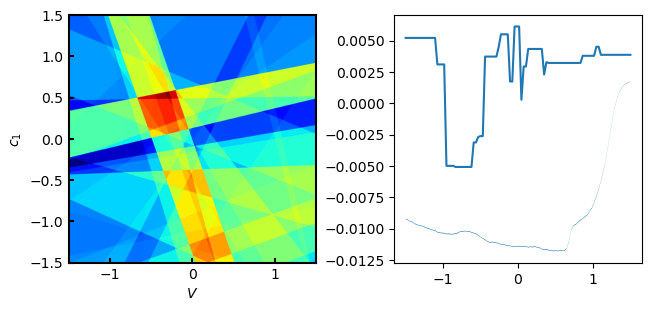

In [22]:
def return_grad_from_input(model, in_ranges, x_in, input_idx, c_idx, cntrl, n):

    v = torch.linspace(in_ranges[0], in_ranges[-1], n)
    in_features = model.layer_dims[0]
    input_tensor_0 = torch.empty(n, in_features)

    input_tensor_0[:, input_idx] = v
    input_tensor_0[:, c_idx] = torch.as_tensor(x_in).unsqueeze(0).expand(n)

    c_counter = 0
    for l in range(in_features):
        if l != input_idx and l != c_idx:
            input_tensor_0[:, l] = torch.as_tensor(cntrl[c_counter]).expand(n)
            c_counter += 1

    input_tensor = input_tensor_0.clone().requires_grad_(True)
    model.eval()
    model.zero_grad()

    y = model(input_tensor)
    y = y.squeeze(-1)

    grads = torch.autograd.grad(
        outputs=y,
        inputs=input_tensor,
        grad_outputs=torch.ones_like(y),
        retain_graph=False,
        create_graph=False,
    )[0]

    grad_return = grads[:, c_idx].detach().cpu().numpy()
    
    return grad_return

n = 2000
controls = [1.5, 1.1, -0.2, -0.9, 0.3, -0.6]
c_ranges = torch.linspace(-1.5, 1.5, n)

grad_l = []
for v in c_ranges:
    c_grad = return_grad_from_input(model=net_uni, in_ranges=[-1.5,1.5,], x_in=v, input_idx=0, c_idx=1, cntrl=controls, n=500)
    grad_l.append(c_grad)

grad_arr = np.array(grad_l)
figure, ax = plt.subplots(ncols=2, constrained_layout=True)

for a in ax:
    a.set_box_aspect(1)

im = ax[0].imshow(grad_arr, origin="lower", extent=[-1.5, 1.5, -1.5, 1.5], cmap='jet')
ax[0].spines[:].set_linewidth(1.5)
ax[0].set_xlabel("$V$")
ax[0].set_ylabel("$c_1$")
ax[0].tick_params(direction='in', which='major', width=1.5)
#cax = figure.add_axes([ax[0].get_position().x1+0.1, ax[0].get_position().y0, 0.02, ax[0].get_position().height])
#plt.colorbar(im, cax=cax)

x = np.linspace(-1.5, 1.5, 100)
kmc = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/sim_uni_n_a=50_0.npz")
ax[1].fill_between(x, kmc["current"]-kmc["sem"], kmc["current"]+kmc["sem"] )

derivative_at_c = return_grad_from_input(model=net_uni, in_ranges=[-1.5, 1.5], x_in=-0.1, input_idx=0, c_idx=1, cntrl=controls, n=100)

ax[1].plot(x, derivative_at_c)

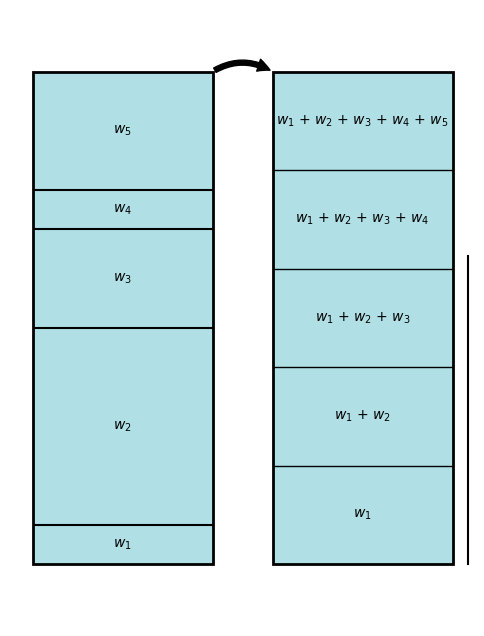

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from itertools import accumulate

def draw_vertical_rects_with_arrow(
    x0=0.1,
    y0=0.2,
    rect_width=1.2,
    rect_height=1.2,
    rect_gap=0.4,
    knot_rel_sizes=None,  # relative segment sizes for left rect
    arrow_rad=-0.3,
    figsize=(6, 8),
):
    # Default: 5 segments => k1..k5
    if knot_rel_sizes is None:
        knot_rel_sizes = [0.1, 0.5, 0.25, 0.1, 0.3]

    n = len(knot_rel_sizes)

    # Normalize to fill full rect_height
    total = sum(knot_rel_sizes)
    rel_norm = [v / total for v in knot_rel_sizes]
    cum_rel = [0] + list(accumulate(rel_norm))  # from 0 to 1

    fig, ax = plt.subplots(figsize=figsize)

    # --- Layout ---
    left_x0 = x0
    left_y0 = y0
    right_x0 = left_x0 + rect_width + rect_gap
    right_y0 = y0

    margin = 0.15
    x_min = left_x0 - margin
    x_max = right_x0 + rect_width + margin
    y_min = max(0.0, left_y0 - margin)
    y_max = left_y0 + rect_height + margin

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- Left rectangle with partitions ---
    rec_1 = Rectangle(
        xy=(left_x0, left_y0),
        width=rect_width,
        height=rect_height,
        fc='powderblue',
        ec='k',
        lw=2.0,
    )
    ax.add_patch(rec_1)

    for i in range(n):
        y_start = left_y0 + cum_rel[i] * rect_height
        y_end = left_y0 + cum_rel[i + 1] * rect_height

        # Inner horizontal boundary (skip bottom; top is outer border)
        if i > 0:
            ax.hlines(
                y=y_start,
                xmin=left_x0,
                xmax=left_x0 + rect_width,
                lw=1.5,
                colors='k'
            )

        # Centered k_i label
        y_mid = 0.5 * (y_start + y_end)
        x_mid = left_x0 + rect_width / 2.0
        ax.text(
            x_mid,
            y_mid,
            rf'$w_{{{i+1}}}$',
            ha='center',
            va='center'
        )

    # --- Right rectangle (cumulative sums) ---
    rec_2 = Rectangle(
        xy=(right_x0, right_y0),
        width=rect_width,
        height=rect_height,
        fc='powderblue',
        ec='k',
        lw=2.0,
    )
    ax.add_patch(rec_2)

    x_mid_r = right_x0 + rect_width / 2.0
    cell_height = rect_height / n  # n rows

    # Draw cumulative sum labels centered in each cell
    for i in range(n):
        # Row i: bottom/top/mid
        y_bottom = right_y0 + i * cell_height
        y_top = y_bottom + cell_height
        y_mid = 0.5 * (y_bottom + y_top)

        # Text: k1, k1 + k2, ..., k1 + ... + k_{i+1}
        terms = [rf'$w_{{{j+1}}}$' for j in range(i + 1)]
        expr = ' + '.join(terms)

        ax.text(
            x_mid_r,
            y_mid,
            expr,
            ha='center',
            va='center'
        )

    # Horizontal lines between rows (inside right rectangle)
    for i in range(1, n):
        y_line = right_y0 + i * cell_height
        ax.hlines(
            y=y_line,
            xmin=right_x0,
            xmax=right_x0 + rect_width,
            lw=1.0,
            colors='k'
        )

    # --- Arrow: top-right of first -> top-left of second ---
    posA = (left_x0 + rect_width, left_y0 + rect_height)
    posB = (right_x0, right_y0 + rect_height)

    arrow = FancyArrowPatch(
        posA=posA,
        posB=posB,
        connectionstyle=f"arc3,rad={arrow_rad}",
        arrowstyle="simple",
        mutation_scale=18,
        lw=1.0,
        color='k',
    )
    ax.add_patch(arrow)

    ax.axvline(x=3, ymin=0.1, ymax=0.6, color='k')

    return fig, ax

# Example
if __name__ == "__main__":
    fig, ax = draw_vertical_rects_with_arrow()
    plt.show()


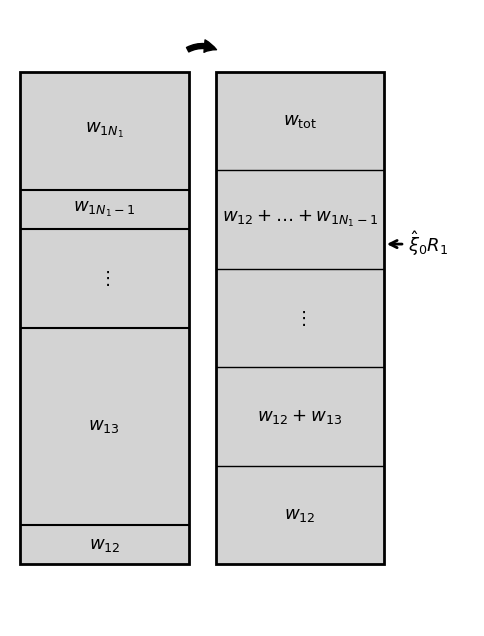

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from itertools import accumulate


def draw_vertical_rects_with_arrow(
    x0=0.1,
    y0=0.2,
    rect_width=2.5,
    rect_height=1.2,
    rect_gap=0.4,
    knot_rel_sizes=None,
    arrow_rad=-0.3,
    figsize=(6, 8),
):
    fontsize = 13
    if knot_rel_sizes is None:
        knot_rel_sizes = [0.1, 0.5, 0.25, 0.1, 0.3]

    n = len(knot_rel_sizes)

    total = sum(knot_rel_sizes)
    rel_norm = [v / total for v in knot_rel_sizes]
    cum_rel = [0] + list(accumulate(rel_norm))

    fig, ax = plt.subplots(figsize=figsize)

    left_x0 = x0
    left_y0 = y0
    right_x0 = left_x0 + rect_width + rect_gap
    right_y0 = y0

    margin = 0.15
    extra_right = 1.2
    extra_top = 0.0

    x_min = left_x0 - margin
    x_max = right_x0 + rect_width + margin + extra_right
    y_min = max(0.0, left_y0 - margin)
    y_max = left_y0 + rect_height + margin + extra_top

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    mid_row = n // 2  # (in "top indexing"); used for dots

    # --- Left rectangle ---
    rec_1 = Rectangle(
        (left_x0, left_y0),
        rect_width,
        rect_height,
        fc="lightgray",
        ec="k",
        lw=2.0,
    )
    ax.add_patch(rec_1)

    for i in range(n):
        # segment geometry is already bottom->top via cum_rel
        y_start = left_y0 + cum_rel[i] * rect_height
        y_end = left_y0 + cum_rel[i + 1] * rect_height

        if i > 0:
            ax.hlines(
                y=y_start,
                xmin=left_x0,
                xmax=left_x0 + rect_width,
                lw=1.5,
                colors="k",
            )

        y_mid = 0.5 * (y_start + y_end)
        x_mid = left_x0 + rect_width / 2.0

        # --- label index: ib=0 at bottom, ib=n-1 at top ---
        ib = i  # since i already counts from bottom upwards

        # bottom-based logic
        if ib == 0:
            txt = r"$w_{1 2}$"
        elif ib == 1:
            txt = r"$w_{1 3}$"
        elif ib == n - 2:
            txt = r"$w_{1 N_1 - 1}$"
        elif ib == n - 1:
            txt = r"$w_{1 N_1}$"
        elif n >= 4 and ib == mid_row:
            txt = r"$\vdots$"
        else:
            txt = ""

        ax.text(x_mid, y_mid, txt, ha="center", va="center", fontsize=fontsize)

    # --- Right rectangle ---
    rec_2 = Rectangle(
        (right_x0, right_y0),
        rect_width,
        rect_height,
        fc="lightgray",
        ec="k",
        lw=2.0,
    )
    ax.add_patch(rec_2)

    x_mid_r = right_x0 + rect_width / 2.0
    cell_height = rect_height / n

    for i in range(n):
        # draw rows bottom->top (same as left)
        y_bottom = right_y0 + i * cell_height
        y_mid = y_bottom + 0.5 * cell_height

        ib = i  # ib=0 bottom

        if ib == 0:
            txt = r"$w_{1 2}$"
        elif ib == 1:
            txt = r"$w_{1 2} + w_{1 3}$"
        elif ib == n - 2:
            txt = r"$w_{1 2} + \ldots + w_{1 N_1 - 1}$"
        elif ib == n - 1:
            txt = r"$w_{\mathrm{tot}}$"
        elif n >= 4 and ib == mid_row:
            txt = r"$\vdots$"
        else:
            txt = ""

        ax.text(x_mid_r, y_mid, txt, ha="center", va="center", fontsize=fontsize)

    for i in range(1, n):
        y_line = right_y0 + i * cell_height
        ax.hlines(
            y=y_line,
            xmin=right_x0,
            xmax=right_x0 + rect_width,
            lw=1.0,
            colors="k",
        )

    # --- Curved arrow between rectangles ---
    posA = (left_x0 + rect_width - 0.05, left_y0 + rect_height + 0.05)
    posB = (right_x0 + 0.05, right_y0 + rect_height + 0.05)
    arrow = FancyArrowPatch(
        posA=posA,
        posB=posB,
        connectionstyle=f"arc3,rad={arrow_rad}",
        arrowstyle="simple",
        mutation_scale=18,
        lw=1.0,
        color="k",
    )
    ax.add_patch(arrow)

    # --- Annotation arrow + text pointing to right rectangle ---
    y_frac = 0.65
    tip = (right_x0 + rect_width, right_y0 + y_frac * rect_height)
    text_pos = (right_x0 + rect_width + 0.35, tip[1])

    ax.annotate(
        r"$\hat{\xi}_0 R_1$",
        xy=tip,
        xytext=text_pos,
        ha="left",
        va="center",
        arrowprops=dict(arrowstyle="->", lw=2),
        fontsize=fontsize,
        clip_on=False,
    )

    return fig, ax


if __name__ == "__main__":
    draw_vertical_rects_with_arrow()
    plt.savefig("kmc_rate_array.pdf", bbox_inches="tight")
    plt.show()


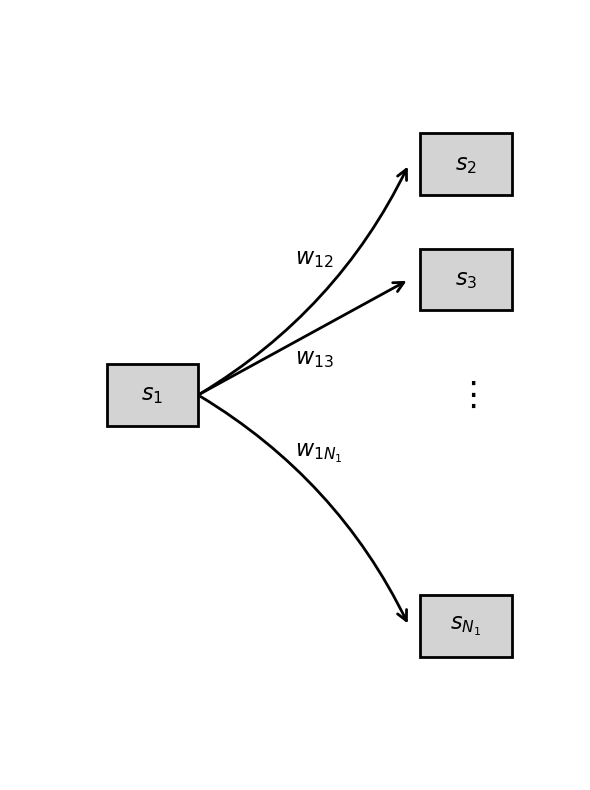

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

def transition_diagram():
    fig, ax = plt.subplots(figsize=(6, 8))

    # Work in axes-fraction coordinates
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.spines[:].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # --- Helper to add a "state" box ---
    def add_state(x, y, w=0.16, h=0.08, label=r"$s$"):
        box = Rectangle((x - w/2, y - h/2), w, h,
                        facecolor="lightgray", edgecolor="k", lw=2,
                        transform=ax.transAxes, clip_on=False)
        ax.add_patch(box)
        ax.text(x, y, label, ha="center", va="center",
                fontsize=16, transform=ax.transAxes)

    # --- Helper to add an arrow (optionally curved) ---
    def add_arrow(xyA, xyB, rad=0.0):
        arr = FancyArrowPatch(
            xyA, xyB,
            arrowstyle="->",
            mutation_scale=18,
            lw=2,
            connectionstyle=f"arc3,rad={rad}",
            transform=ax.transAxes,
            clip_on=False,
            color="k",
        )
        ax.add_patch(arr)

    # Source state
    add_state(0.25, 0.50, label=r"$s_1$")

    # Target states (show a few + ellipsis)
    targets_y = [0.80, 0.65, 0.20]   # top, mid, bottom (visible examples)
    labels    = [r"$s_2$", r"$s_3$", r"$s_{N_1}$"]

    for y, lab, rad in zip(targets_y, labels, [0.15, 0.0, -0.15]):
        add_state(0.80, y, label=lab)
        add_arrow((0.33, 0.50), (0.70, y), rad=rad)

    # Ellipsis to indicate "many more targets"
    ax.text(0.80, 0.50, r"$\vdots$", fontsize=24,
            ha="center", va="center", transform=ax.transAxes)

    #ax.text(0.5, 0.95, "Transitions from state $i$ to multiple other states",
    #        ha="center", va="center", fontsize=14, transform=ax.transAxes)
    ax.text(x=0.5, y=0.67, s=r'$w_{1 2}$', fontsize=16)
    ax.text(x=0.5, y=0.54, s=r'$w_{1 3}$', fontsize=16)
    ax.text(x=0.5, y=0.42, s=r'$w_{1 N_1}$', fontsize=16)

    plt.tight_layout()
    return fig, ax

if __name__ == "__main__":
    transition_diagram()
    plt.savefig("kmc_transitions.pdf", bbox_inches="tight")

## LHC

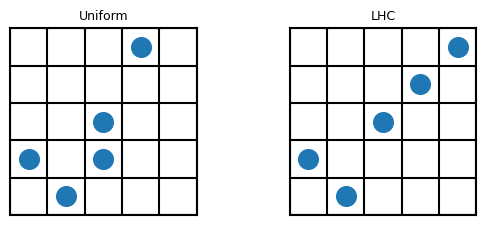

In [16]:
import numpy as np
import matplotlib.pyplot as plt

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

# ---- Simple Latin Hypercube sampler on [0,1]^d ----
def latin_hypercube(n_samples, n_dim, rng=None):
    if rng is None:
        rng = np.random.default_rng()
        
    # Split [0,1] into n_samples strata
    cut = np.linspace(0, 1, n_samples + 1)
    
    # Random point in each stratum (1D)
    u = rng.random((n_samples, n_dim))
    a = cut[:-1]
    b = cut[1:]
    points = a[:, None] + (b - a)[:, None] * u  # shape (n_samples, n_dim)

    # Permute strata independently in each dimension
    lhs = np.zeros_like(points)
    for j in range(n_dim):
        perm = rng.permutation(n_samples)
        lhs[:, j] = points[perm, j]
    return lhs

# ---- Main: 2D random vs LHC ----
rng = np.random.default_rng(0)
n_samples = 6  # small-ish to see the pattern

# Random uniform and LHC samples in [0,1]^2
#random_samples = rng.random((n_samples, 2))
#lhs_samples = latin_hypercube(n_samples, 2, rng)

step = 0.1
random_samples = np.array([
    [step, 3*step],
    [5 * step, 3*step],
    [3 * step, step],
    [5 * step, 5 * step],
    [7 * step, 9 * step]   
])

lhs_samples = np.array([
    [step, 3*step],
    [3 * step, step],
    [5 * step, 5 * step],
    [7 * step, 7 * step],
    [9 * step, 9 * step],
])

fig, axes = plt.subplots(1, 2, figsize=(width_in_pt, height_in_pt * 0.618), constrained_layout=True)

for a in axes:
    a.set_box_aspect(1)

# Helper to draw the strata grid
def draw_grid(ax, n):
    ticks = np.linspace(0, 1, n + 1)
    for t in ticks:
        ax.axhline(t, linewidth=0.5, alpha=0.3)
        ax.axvline(t, linewidth=0.5, alpha=0.3)

ticks = np.linspace(0, 1, n_samples)

# ---- Left: pure random ----
ax = axes[0]
ax.scatter(*random_samples.T, s=200, alpha=1.0, zorder=5)
#draw_grid(ax, n_samples)  # same number of strata as samples (for comparison)

ax.set_title("Uniform")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines[:].set_linewidth(1.5)
ax.grid(lw=1.5, c='k')
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelright=False, labelleft=False)

# ---- Right: Latin hypercube ----
ax = axes[1]
ax.scatter(*lhs_samples.T, s=200, alpha=1.0, zorder=5)
#draw_grid(ax, n_samples)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_title("LHC")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines[:].set_linewidth(1.5)
ax.grid(lw=1.5, c='k')

ax.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labeltop=False, labelright=False, labelleft=False)

plt.savefig('lhc_vs_uniform.pdf', bbox_inches='tight')